# Redshift and K-corrections in the ArtPop fork — the tests, drawn

**What this notebook is for.** `ArtPop/tests/test_redshift.py` and
`redshift_tests.py` between them make about forty assertions about how a
synthetic stellar population behaves when you move it to non-zero redshift.
Each one reads out as a line of text and a number. Most of them encode a
*physical* claim rather than a plumbing invariant, and the reasoning behind them
lives in 40 kB of prose in `HANDOFF_REDSHIFT.md`.

This notebook draws them. Roughly one cell per claim: a plain-language statement
of **what is being tested and why it matters**, the check's own verdict printed
verbatim, and then a figure of the physics it is asserting — drawn from the same
arrays the assertion was made on, so a plot cannot disagree with the verdict
above it.

---

## The one-paragraph version of the physics

ArtPop has been strictly `z = 0` and Euclidean. Distance entered through a single
scalar, `5 log10(D_L/10 pc)`, added to rest-frame MIST magnitudes computed
through rest-frame filter curves — and the *same* scalar was reused to convert a
physical size into an angle. That identity holds only at `z = 0`.

Three things change:

1. **A per-star K-correction.** Redshifting a source is exactly blueshifting the
   filter, so each star picks up
   `K = -2.5 log10[(1+z) ∫L(λ)T((1+z)λ)λdλ / ∫L(λ)T(λ)λdλ]`. It is applied
   *differentially*, on top of MIST's shipped magnitudes, using the spectral
   libraries MIST itself integrated (C3K and Tremblay+2011).
2. **Two dust frames.** Dust inside the host galaxy reddens the star's
   rest-frame spectrum; Milky Way foreground attenuates observer-frame
   wavelengths. At `z = 0` these coincide. At `z > 0` they do not.
3. **Two distances.** Flux runs on `D_L`; angles run on `D_A = D_L/(1+z)²`.
   `distance`, `redshift` and `r_eff` stay three free arguments — nothing
   derives any of them from another — because cosmology is a *target* here, not
   an input.

## Contents

| § | what it establishes |
|---|---|
| **R0** | setup, and the two test suites |
| **R1** | why the correction cannot be one number per galaxy |
| **R2** | the analytic identities that pin the bookkeeping |
| **R3** | the spectral libraries, the grid, and the seams between them |
| **R4** | integration with the isochrone, population and source layers |
| **R5** | the two dust frames |
| **R6** | geometry, and the term nothing in the code computes |
| **R7** | the error budget: is the signal bigger than the systematic? |
| **R8** | what is settled and what is still open |


---
## §R0 — Setup

Two suites feed this notebook, and they are deliberately different in style.

* **`ArtPop/tests/test_redshift.py`** — the fork's own `unittest` suite, 37
  tests. It is the regression gate, it runs in CI, and most of it needs neither
  MIST nor a network (Tier A is pure math; Tier C runs on the 10 Gyr test
  isochrone that ships inside the package). Cells that surface one of these run
  the whole suite once, then quote the verdict and **redraw the physics
  independently** — the same pattern §H of `visualize_tests.ipynb` uses.
* **`redshift_tests.py`** — twelve physically-loaded checks in the
  `alviss_tests.py` house style, each returning `(status, detail)` or, with
  `diag=True`, `(status, detail, d)` where `d` holds the arrays the assertion
  was computed from. **Every figure below is drawn from that `d`**, which is why
  a figure cannot disagree with the verdict printed above it.

**Cost.** The setup cells run both suites once: about 3 minutes for the fork
tests and about 6 for the checks. Everything after that is instant.

In [1]:
import os, sys, io, time, textwrap, warnings, unittest

# Several checks need MORE than the isochrone grids: `check_mist_av_roundtrip`
# reads MIST's bolometric-correction tables (bcl/ and bc/) to recover the
# reddening law MIST used. ~/.artpop/mist carries the grids only, so pick a root
# that has both rather than the first one that has either -- otherwise the
# affected checks SKIP and the failure surfaces twenty cells later.
def _complete(root):
    return all(os.path.exists(os.path.join(root, p)) for p in
               ("MIST_v2.5_LSST", "MIST_v2.5_Roman", "bcl", "bc"))


_cands = [c for c in (os.environ.get("ALVISS_VIZ_MIST_PATH"), "/opt/mist",
                      os.path.expanduser("~/.artpop/mist")) if c]
_mist = next((c for c in _cands if _complete(c)), _cands[0])
os.environ["MIST_PATH"] = _mist

warnings.filterwarnings("ignore", message=".*isiterable.*")
warnings.filterwarnings("ignore", message=".*no units.*")
warnings.filterwarnings("ignore", message=".*has no units.*")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

# resolve the two roots from wherever the notebook is opened, rather than
# hardcoding them: this file lives in ArtPop/ but `redshift_tests.py` is one
# level up, and either directory is a plausible working directory.
def _find_up(marker, start=None, levels=3):
    d = os.path.abspath(start or os.getcwd())
    for _ in range(levels + 1):
        if os.path.exists(os.path.join(d, marker)):
            return d
        for sub in ("ArtPop",):
            if os.path.exists(os.path.join(d, sub, marker)):
                return os.path.join(d, sub)
        d = os.path.dirname(d)
    raise FileNotFoundError(f"could not locate {marker} from {os.getcwd()}")


FORK = _find_up(os.path.join("src", "artpop", "__init__.py"))
REPO = _find_up("redshift_tests.py")
sys.path.insert(0, REPO)
sys.path.insert(0, os.path.join(FORK, "src"))
import artpop
import redshift_tests as rt
from artpop.kcorrect import (KCorrectionGrid, C3KLibrary, TremblayWDLibrary,
                             band_offset, k_correction, band_weights,
                             extinction_curve, planck_lam, spectra_path,
                             SOURCE_NAMES, SOURCE_C3K, SOURCE_WD, SOURCE_BB)
from artpop.filters import load_filter_system

# HANDOFF_MIST.md s4: without the right path, `import artpop` silently falls
# back to a stock install and every MIST cell tests the wrong code.
print("fork      :", FORK)
print("repo      :", REPO)
print("artpop    :", artpop.__file__)
assert os.path.abspath(artpop.__file__).startswith(os.path.abspath(FORK)), \
    "NOT the patched fork -- see HANDOFF_MIST.md s4"
print("MIST      :", rt.MIST_PATH, "v" + rt.MIST_VERSION)
print("spectra   :", spectra_path())
print("C3K / WD  :", C3KLibrary().available, "/", TremblayWDLibrary().available)
print("z_ref     :", rt.Z_REF)

# fail here, with a message, rather than twenty cells later with a KeyError
_missing = [n for n, ok in (
    ("MIST v2.5 isochrone grids", _complete(_mist)),
    ("C3K spectral library", C3KLibrary().available),
    ("Tremblay WD library", TremblayWDLibrary().available)) if not ok]
assert not _missing, (
    f"not staged: {_missing}. MIST_PATH must hold MIST_v2.5_{{LSST,Roman}} AND "
    "the bcl/ and bc/ bolometric-correction tables; the spectral libraries are "
    "under $ALVISS_SPECTRA_PATH -- see data/spectral_libraries/PROVENANCE.md.")
print("\nall inputs staged")

fork      : /workspace/ArtPop
repo      : /workspace
artpop    : /workspace/ArtPop/src/artpop/__init__.py
MIST      : /opt/mist v2.5
spectra   : /workspace/data/spectral_libraries
C3K / WD  : True / True
z_ref     : 0.05

all inputs staged


In [2]:
# ----------------------------------------------------------------- house style
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 9.5, "axes.titleweight": "bold",
    "legend.frameon": False, "legend.fontsize": 8,
    "image.origin": "lower", "image.interpolation": "nearest",
})

C = {"ours": "#1f6fb4", "theirs": "#c8501e", "truth": "#2f2f2f",
     "alt": "#7a3fa0", "ok": "#2e7d46", "bad": "#b3261e",
     "band": "#1f6fb4", "muted": "#8a8a8a", "smooth": "#4c9f70",
     "sampled": "#e0a33e"}

# one colour per LSST band, blue to red, used everywhere below
BANDC = {"LSST_u": "#5b3ea8", "LSST_g": "#2e7d46", "LSST_r": "#c8501e",
         "LSST_i": "#a0342a", "LSST_z": "#7a2f4a", "LSST_y": "#4a4a4a"}
BACKC = {"C3K": "#1f6fb4", "Tremblay": "#e0a33e", "blackbody": "#b3261e"}

_BANNER = {"PASS": ("✅", "#2e7d46"), "FAIL": ("❌", "#b3261e"),
           "SKIP": ("⏭", "#8a8a8a")}


def show(status, detail, width=100):
    """The check's own verdict, printed verbatim above its figure."""
    mark, _ = _BANNER.get(status, ("?", "#000"))
    print(f"{mark}  {status}")
    for para in str(detail).splitlines():
        for line in textwrap.wrap(para, width) or [""]:
            print("    " + line)


def tolband(ax, centre, halfwidth, label=None, color=C["muted"], orient="h"):
    """Shade the tolerance the check actually applies."""
    f = ax.axhspan if orient == "h" else ax.axvspan
    f(centre - halfwidth, centre + halfwidth, color=color, alpha=0.15,
      lw=0, label=label)


def verdict_table(names, results, notes):
    """A compact PASS/FAIL table for the checks whose content is a number."""
    w = max(len(n) for n in names)
    for n in names:
        st = results.get(n, ("SKIP", ""))[0]
        mark = _BANNER.get(st, ("?", ""))[0]
        print(f"  {mark} {st:<5} {n:<{w}}  {notes.get(n, '')}")


print("helpers ready")

helpers ready


In [3]:
# ------------------------------------------------- run the fork suite, once
# Each fork-test cell below quotes this verdict and then redraws the physics
# from scratch, so the picture is an independent statement of the same claim.
sys.path.insert(0, os.path.join(FORK, "tests"))
import test_redshift as trm


def _flatten(suite):
    for t in suite:
        if isinstance(t, unittest.TestSuite):
            yield from _flatten(t)
        else:
            yield t


def _run_fork_suite():
    suite = unittest.defaultTestLoader.loadTestsFromModule(trm)
    # collect the ids BEFORE running: TestSuite drops each case to None as it
    # goes, to free memory, so iterating afterwards yields Nones
    ids = [t.id().split(".", 1)[-1] for t in _flatten(suite)]
    buf = io.StringIO()
    res = unittest.TextTestRunner(stream=buf, verbosity=0).run(suite)
    out = {i: ("PASS", "") for i in ids}
    for t, tb in res.failures + res.errors:
        out[t.id().split(".", 1)[-1]] = ("FAIL", tb[-900:])
    for t, why in res.skipped:
        out[t.id().split(".", 1)[-1]] = ("SKIP", why)
    return out


_t0 = time.time()
FORK = _run_fork_suite()
print(f"ArtPop/tests/test_redshift.py: {sum(v[0] == 'PASS' for v in FORK.values())} "
      f"passed, {sum(v[0] == 'FAIL' for v in FORK.values())} failed, "
      f"{sum(v[0] == 'SKIP' for v in FORK.values())} skipped "
      f"({time.time() - _t0:.0f} s)")


def fork_test(name):
    """One fork test's verdict, house-style."""
    status, detail = FORK.get(name, ("SKIP", "no such test"))
    msg = f"ArtPop/tests/test_redshift.py::{name}"
    if status != "PASS" and detail:
        msg += "\n" + detail
    return status, msg

ArtPop/tests/test_redshift.py: 37 passed, 0 failed, 0 skipped (9 s)


In [4]:
# ------------------------------------------ run the twelve checks, once
# Called with diag=True so each returns (status, detail, d). Every figure below
# is drawn from these same `d` dicts -- see VISUALIZE_TESTS.md s2 for why that
# matters: a plot drawn from a recomputed setup can quietly disagree with the
# assertion printed above it.
RT = {}
_t0 = time.time()
for _name, _fn, _slow in rt.CHECKS:
    _t = time.time()
    RT[_name] = _fn(diag=True)
    print(f"  {RT[_name][0]:<5} {_name:<28} {time.time() - _t:6.1f} s")
print(f"\nredshift_tests.py: "
      f"{sum(v[0] == 'PASS' for v in RT.values())} passed, "
      f"{sum(v[0] == 'FAIL' for v in RT.values())} failed, "
      f"{sum(v[0] == 'SKIP' for v in RT.values())} skipped "
      f"({time.time() - _t0:.0f} s)")

  PASS  k_star_spread                   0.7 s


  PASS  k_int_vs_sbf                    2.3 s


  PASS  redshift_zero_noop              2.6 s
  PASS  kgrid_backends                  0.0 s


  PASS  resolution_systematic           1.9 s
  PASS  feh_lookup_sensitivity          0.0 s


  PASS  mist_av_roundtrip               0.6 s
  PASS  extinction_frames               0.2 s


  PASS  distance_flux_power             1.9 s


  PASS  surface_brightness_dimming      1.4 s


  PASS  distance_redshift_separable     1.3 s


  PASS  error_budget                    1.5 s

redshift_tests.py: 12 passed, 0 failed, 0 skipped (14 s)


---
# §R1 — Why the correction cannot be one number per galaxy

The tempting shortcut is to compute one K-correction for a galaxy and add it to
every magnitude. It is wrong, and the two cells below are the measurement that
says so.

A K-correction depends on the **shape** of the spectrum it is applied to. The
stars in a single old population span 3 500 K to 100 000 K, so their spectra have
wildly different shapes, so their K-corrections differ. That means the
correction changes the *shape* of the colour-magnitude diagram, not its zero
point — which in turn means it moves which stars pass a magnitude limit, moves
the integrated colour, and moves the surface-brightness fluctuation signal, all
by different amounts.

### R1.1 · `check_k_star_spread` — K is a property of a star, not of a galaxy

**What is being tested.** Take a real 10 Gyr, [Fe/H] = −1 MIST isochrone, put it
at `z = 0.05` (the far edge of ALVISS's 20–200 Mpc distance prior), and compute
each star's K-correction from the spectral libraries MIST itself integrated.
Then ask how much the answer varies from star to star within that one
population.

**Why it matters.** If the spread were small — a few hundredths of a magnitude —
a single per-galaxy number would be a fine approximation and none of this
machinery would be worth building. The check fails if the spread is under
0.05 mag, i.e. it is written so that "the shortcut is fine" is a possible
outcome.

**What the figure shows.** Left: every isochrone row's K in the bluest and
reddest LSST bands, against temperature, with the five landmark stars of the
CMD marked. Right: the full spread, band by band. The correction is a *function
of temperature*, and a strongly non-monotonic one in `u`.

✅  PASS
    K spread across one population at z=0.05: u=0.421  g=0.359  r=0.191  i=0.160  z=0.123  y=0.098
    F106=0.100  F129=0.101  F158=0.119  F184=0.040 mag -- far too large to be a per-galaxy scalar


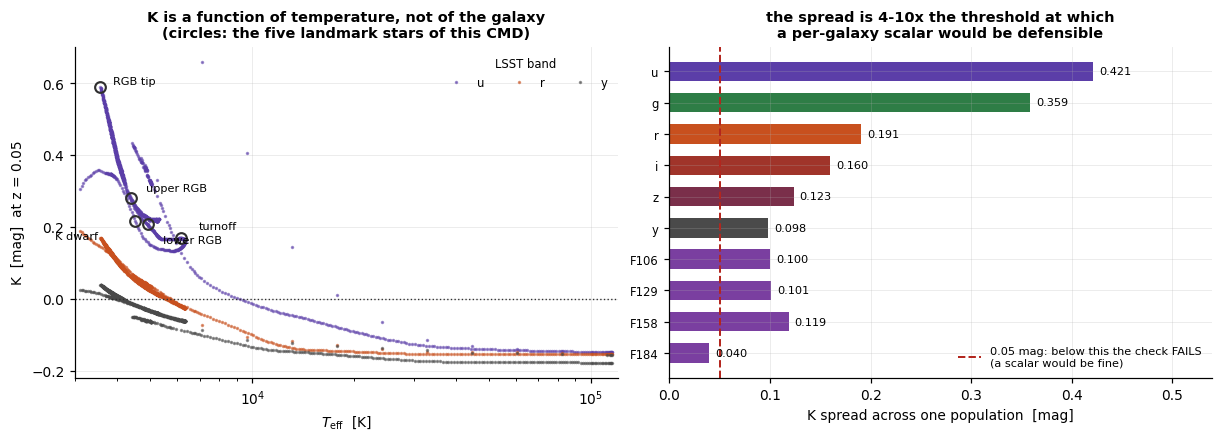

In [5]:
status, detail, d = RT["k_star_spread"]
show(status, detail)

lt = np.array(d["log_teff"]); teff = 10 ** lt
w = np.array(d["imf_weight"]) * 10 ** (-0.4 * np.array(d["mag_r"]))
w = w / w.max()

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.9), constrained_layout=True)

ax = axes[0]
for band in ("LSST_u", "LSST_r", "LSST_y"):
    k = np.array(d["k_all"][band])
    o = np.argsort(teff)
    ax.plot(teff[o], k[o], ".", ms=2.5, color=BANDC[band], alpha=0.55,
            label=band.split("_")[-1])
# the five landmarks sit close together on this axis, so the labels are
# offset by hand rather than left to collide
_off = {"RGB tip": (8, 2), "upper RGB": (10, 4), "lower RGB": (10, -12),
        "turnoff": (12, 6), "K dwarf": (-52, -12)}
for (label, t, g, vals), idx in zip(d["rows"], d["case_index"]):
    ku = d["k_all"]["LSST_u"][idx]
    ax.plot(t, ku, "o", ms=7, mfc="none", mec=C["truth"], mew=1.4, zorder=5)
    ax.annotate(label, (t, ku), textcoords="offset points",
                xytext=_off.get(label, (6, 5)), fontsize=7.4, zorder=6)
ax.axhline(0, color=C["truth"], lw=0.9, ls=":")
ax.set_xscale("log"); ax.set_xlim(3000, 1.2e5)
ax.set_xlabel(r"$T_{\rm eff}$  [K]"); ax.set_ylabel(f"K  [mag]  at z = {d['z']}")
ax.set_title("K is a function of temperature, not of the galaxy\n"
             "(circles: the five landmark stars of this CMD)")
ax.legend(title="LSST band", fontsize=7.6, title_fontsize=7.6, ncol=3)

ax = axes[1]
bands = [b.split("_")[-1] for b in d["bands"]]
y = np.arange(len(bands))
ax.barh(y, d["spread"], 0.62,
        color=[BANDC.get("LSST_" + b, C["alt"]) for b in bands])
ax.axvline(0.05, color=C["bad"], lw=1.3, ls="--",
           label="0.05 mag: below this the check FAILS\n(a scalar would be fine)")
for i, v in enumerate(d["spread"]):
    ax.text(v + 0.006, i, f"{v:.3f}", va="center", fontsize=7.4)
ax.set_yticks(y); ax.set_yticklabels(bands, fontsize=7.6)
ax.invert_yaxis(); ax.set_xlim(0, max(d["spread"]) * 1.28)
ax.set_xlabel("K spread across one population  [mag]")
ax.set_title("the spread is 4-10x the threshold at which\n"
             "a per-galaxy scalar would be defensible")
ax.legend(loc="lower right", fontsize=7.4)
plt.show()

### R1.2 · `check_k_int_vs_sbf` — and the SBF correction is not the integrated-light one

**What is being tested.** The same population, two different weightings. Total
light is weighted by each star's flux `f`; the surface-brightness fluctuation
magnitude `m̄ = Σnf² / Σnf` is weighted by `f²`. Apply the per-star corrections
and ask how much each moves.

**Why it matters.** This is the reason the correction has to live *inside* the
renderer rather than being applied to catalogue columns afterwards. `f²`
weighting is dominated by the tip of the red giant branch — the coolest and
therefore most strongly corrected stars in the population — so `m̄` moves
further than the integrated light does. And `m̄` is a distance indicator:
0.2 mag on `m̄` is about 10% in SBF distance. A single per-galaxy correction
gets it wrong *by construction*, and would look entirely reasonable while doing
so.

**What the figure shows.** Left: the two corrections, band by band. The
integrated-light correction crosses zero and goes negative in the red; the SBF
one stays positive everywhere. Right: the difference between them, against the
0.06–0.20 mag range the original CK04 prototype predicted before the proper
libraries were staged.

✅  PASS
    |K_SBF - K_int| = 0.021-0.180 mag at z=0.05 (log_age=10.0, feh=-1.0); K_int changes sign across the
    bands (-0.121 to +0.181) while K_SBF does not (-0.099 to +0.297)


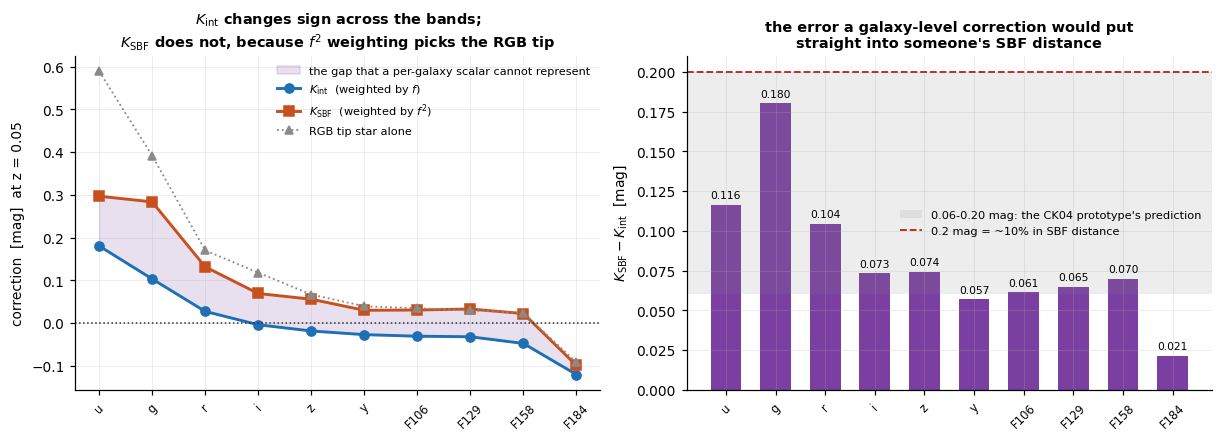

In [6]:
status, detail, d = RT["k_int_vs_sbf"]
show(status, detail)

rows = d["rows"]
labels = [r[0].replace("LSST_", "").replace("Roman_", "") for r in rows]
k_int = np.array([r[1] for r in rows]); k_sbf = np.array([r[2] for r in rows])
diff = np.array([r[3] for r in rows]); k_tip = np.array([r[4] for r in rows])
x = np.arange(len(rows))

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.9), constrained_layout=True)

ax = axes[0]
ax.fill_between(x, k_int, k_sbf, color=C["alt"], alpha=0.16,
                label="the gap that a per-galaxy scalar cannot represent")
ax.plot(x, k_int, "o-", lw=1.9, color=C["ours"], label=r"$K_{\rm int}$  (weighted by $f$)")
ax.plot(x, k_sbf, "s-", lw=1.9, color=C["theirs"], label=r"$K_{\rm SBF}$  (weighted by $f^2$)")
ax.plot(x, k_tip, "^:", lw=1.2, ms=5, color=C["muted"], label="RGB tip star alone")
ax.axhline(0, color=C["truth"], lw=1.0, ls=":")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=7.6, rotation=45)
ax.set_ylabel(f"correction  [mag]  at z = {d['z']}")
ax.set_title(r"$K_{\rm int}$ changes sign across the bands;"
             "\n" r"$K_{\rm SBF}$ does not, because $f^2$ weighting picks the RGB tip")
ax.legend(fontsize=7.4)

ax = axes[1]
ax.bar(x, diff, 0.62, color=C["alt"])
tolband(ax, 0.13, 0.07, "0.06-0.20 mag: the CK04 prototype's prediction",
        color=C["muted"])
ax.axhline(0.2, color=C["bad"], lw=1.2, ls="--",
           label="0.2 mag = ~10% in SBF distance")
for i, v in enumerate(diff):
    ax.text(i, v + 0.004, f"{v:.3f}", ha="center", fontsize=7.0)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=7.6, rotation=45)
ax.set_ylabel(r"$K_{\rm SBF} - K_{\rm int}$  [mag]")
ax.set_title("the error a galaxy-level correction would put\n"
             "straight into someone's SBF distance")
ax.legend(fontsize=7.4)
plt.show()

---
# §R2 — The analytic identities that pin the bookkeeping

There are two ways a K-correction implementation goes wrong, and neither
announces itself.

The first is **dropping the `(1+z)` prefactor**. The integral has a leading
`(1+z)` that comes from the bandwidth compression — a fixed observer-frame
filter accepts a wider rest-frame range at higher `z`. Leaving it out produces
values that are still small, still smooth, still ordered correctly by
temperature, and wrong by exactly `2.5 log10(1+z)` in every band.

The second is a **convention mismatch**: energy-counting instead of
photon-counting, or a factor of `λ` in the wrong place. Same symptom — plausible
numbers, silently wrong.

Both are caught by identities that hold exactly, for spectra whose answer can be
written down in closed form. These eight tests need no MIST grid, no spectral
library, and no network.

### R2.1 · `test_a2_power_law_identity` — the `(1+z)` prefactor

**What is being tested.** For a power-law spectrum `f_ν ∝ ν^α` the K-correction
has a closed form in *any* filter: `K = −2.5(1+α) log₁₀(1+z)`. The test evaluates
the real integrator for four values of `α` and three redshifts in all six LSST
bands and compares against that formula.

**Why it matters.** This is the sharpest available test of the prefactor,
because the error it catches is a clean, constant offset that no smoothness or
ordering check would notice. The right-hand panel draws what a dropped prefactor
would look like: an error thirty thousand times the tolerance.

**Note `α = −1`.** That gives `K = 0` identically, in every band and at every
redshift — a free "no-op spectrum" test, which is `test_a3`.

✅  PASS
    ArtPop/tests/test_redshift.py::TestRedshiftAnalytic.test_a2_power_law_identity


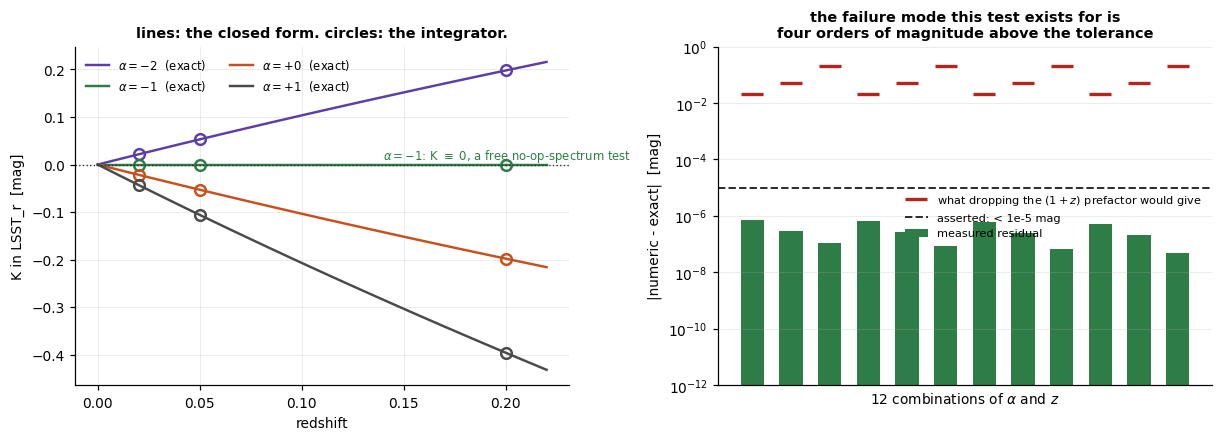

In [7]:
status, detail = fork_test("TestRedshiftAnalytic.test_a2_power_law_identity")
show(status, detail)

fs = load_filter_system("LSST")
lam = np.geomspace(500.0, 60000.0, 40000)
alphas = [-2.0, -1.0, 0.0, 1.0]
zs = np.array([0.02, 0.05, 0.2])
band = "LSST_r"
tw, tt = fs.get_trans(band)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.9), constrained_layout=True)
ax = axes[0]
zz = np.linspace(0, 0.22, 60)
for a, col in zip(alphas, ["#5b3ea8", "#2e7d46", "#c8501e", "#4a4a4a"]):
    ax.plot(zz, -2.5 * (1 + a) * np.log10(1 + zz), "-", lw=1.6, color=col,
            label=fr"$\alpha={a:+.0f}$  (exact)")
    ax.plot(zs, [k_correction(lam, lam ** (-(a + 2.0)), tw, tt, z) for z in zs],
            "o", ms=7, mfc="none", mec=col, mew=1.6)
ax.axhline(0, color=C["truth"], lw=0.9, ls=":")
ax.annotate(r"$\alpha=-1$: K $\equiv$ 0, a free no-op-spectrum test",
            (0.14, 0.012), fontsize=7.6, color="#2e7d46")
ax.set_xlabel("redshift"); ax.set_ylabel(f"K in {band}  [mag]")
ax.set_title("lines: the closed form. circles: the integrator.")
ax.legend(fontsize=7.6, ncol=2)

ax = axes[1]
resid, wrong = [], []
for a in alphas:
    sed = lam ** (-(a + 2.0))
    for z in zs:
        k = k_correction(lam, sed, tw, tt, z)
        resid.append(abs(k - (-2.5 * (1 + a) * np.log10(1 + z))))
        wrong.append(2.5 * np.log10(1 + z))
x = np.arange(len(resid))
ax.bar(x, np.maximum(resid, 1e-12), 0.6, color=C["ok"], label="measured residual")
ax.plot(x, wrong, "_", ms=14, mew=2.2, color=C["bad"],
        label=r"what dropping the $(1+z)$ prefactor would give")
ax.axhline(1e-5, color=C["truth"], lw=1.3, ls="--", label="asserted: < 1e-5 mag")
ax.set_yscale("log"); ax.set_ylim(1e-12, 1)
ax.set_xticks([]); ax.set_xlabel(r"12 combinations of $\alpha$ and $z$")
ax.set_ylabel("|numeric - exact|  [mag]")
ax.set_title("the failure mode this test exists for is\n"
             "four orders of magnitude above the tolerance")
ax.legend(fontsize=7.4, loc="center right")
plt.show()

### R2.2 · `test_a4_blackbody_identity` — the photon-counting convention

**What is being tested.** A redshifted blackbody *is* a blackbody, at
temperature `T/(1+z)`. Push that through the definition of a bolometric
correction and every factor cancels, leaving

`K(z, T) = BC(T) − BC(T/(1+z))`,

exactly, with no free parameters. The test computes the left-hand side with the
K-correction integrator and the right-hand side with the bolometric-correction
integrator, and demands they agree.

**Why it matters.** These two integrals are used in different places for
different jobs, and nothing else forces them to share a convention. If one
counted energy and the other counted photons, or if a `(1+z)` were hiding in one
of them, the difference would show up here and essentially nowhere else. It is
also the exact identity that the blackbody fallback backend relies on, for the
handful of stars that neither production library covers.

**What the figure shows.** The two sides, for three temperatures and two
redshifts, and their difference against the tolerance.

✅  PASS
    ArtPop/tests/test_redshift.py::TestRedshiftAnalytic.test_a4_blackbody_identity


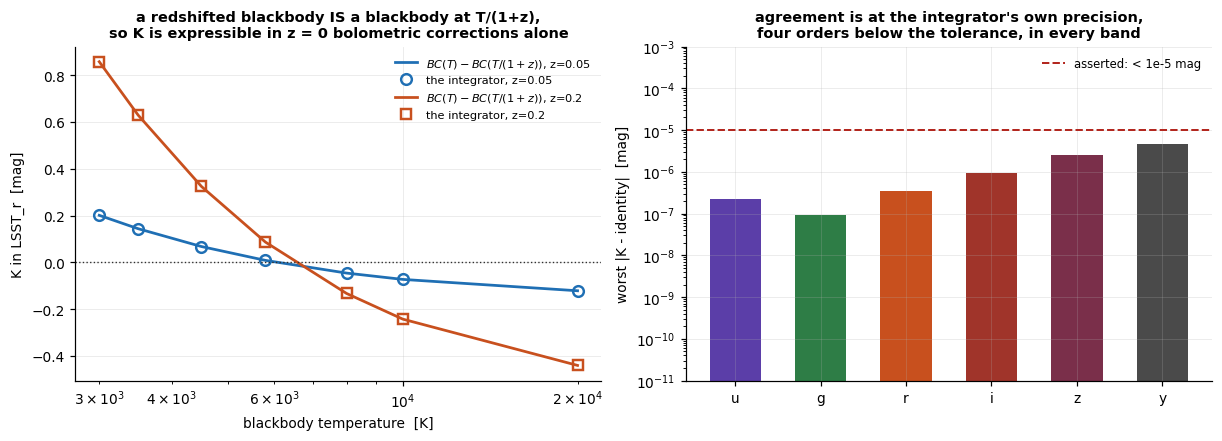

In [8]:
status, detail = fork_test("TestRedshiftAnalytic.test_a4_blackbody_identity")
show(status, detail)

SIGMA = 5.670374419e-5
temps = np.array([3000., 3500., 4500., 5800., 8000., 10000., 20000.])
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.9), constrained_layout=True)

ax = axes[0]
for z, col, mk in ((0.05, C["ours"], "o"), (0.2, C["theirs"], "s")):
    def bc(T):
        w = band_weights(lam, tw, tt, 0.0)
        return 2.5 * np.log10(np.dot(planck_lam(lam, T), w)) - 2.5 * np.log10(SIGMA * T ** 4)
    ident = np.array([bc(T) - bc(T / (1 + z)) for T in temps])
    numeric = np.array([k_correction(lam, planck_lam(lam, T), tw, tt, z) for T in temps])
    ax.plot(temps, ident, "-", lw=1.8, color=col, label=fr"$BC(T)-BC(T/(1+z))$, z={z}")
    ax.plot(temps, numeric, mk, ms=7, mfc="none", mec=col, mew=1.6,
            label=f"the integrator, z={z}")
ax.set_xscale("log"); ax.axhline(0, color=C["truth"], lw=0.9, ls=":")
ax.set_xlabel("blackbody temperature  [K]"); ax.set_ylabel(f"K in {band}  [mag]")
ax.set_title("a redshifted blackbody IS a blackbody at T/(1+z),\n"
             "so K is expressible in z = 0 bolometric corrections alone")
ax.legend(fontsize=7.4)

ax = axes[1]
res = []
for b in ["LSST_u", "LSST_g", "LSST_r", "LSST_i", "LSST_z", "LSST_y"]:
    w_, t_ = fs.get_trans(b)
    def bcb(T):
        return (2.5 * np.log10(np.dot(planck_lam(lam, T), band_weights(lam, w_, t_, 0.0)))
                - 2.5 * np.log10(SIGMA * T ** 4))
    worst = max(abs(k_correction(lam, planck_lam(lam, T), w_, t_, z)
                    - (bcb(T) - bcb(T / (1 + z))))
                for T in (3500., 5800., 10000.) for z in (0.05, 0.2))
    res.append((b, worst))
ax.bar(range(len(res)), [max(r[1], 1e-14) for r in res], 0.6,
       color=[BANDC[r[0]] for r in res])
ax.axhline(1e-5, color=C["bad"], lw=1.3, ls="--", label="asserted: < 1e-5 mag")
ax.set_yscale("log"); ax.set_ylim(1e-11, 1e-3)
ax.set_xticks(range(len(res)))
ax.set_xticklabels([r[0].split("_")[-1] for r in res])
ax.set_ylabel("worst |K - identity|  [mag]")
ax.set_title("agreement is at the integrator's own precision,\n"
             "four orders below the tolerance, in every band")
ax.legend(fontsize=7.6)
plt.show()

### R2.3 · `a1`, `a3`, `a6` — the three things that must be *exactly* right

**What is being tested.**

* **`a1`** — at `z = 0` the correction is `0.0` exactly, not "small". The
  numerator and denominator of the integral are computed by the same code with
  the same arguments, so they are bit-identical and the ratio is exactly one.
* **`a3`** — the `α = −1` spectrum gives zero at every redshift. Whatever is
  left is the numerical integrator, not the physics.
* **`a6`** — multiplying the spectrum by any constant changes nothing. The
  correction depends only on the *shape*.

**Why they matter.** `a1` is what makes `redshift=0.0` a byte-for-byte no-op all
the way to a rendered image — the regression gate for this whole change. `a6` is
the property that lets the spectral library be used at all without ever
calibrating its absolute flux against MIST's; read the other way, it is also
why the library has to be MIST's *own*, since shape is precisely where libraries
disagree.

✅  PASS
    ArtPop/tests/test_redshift.py::TestRedshiftAnalytic.test_a1_zero_redshift_is_exactly_zero
✅  PASS
    ArtPop/tests/test_redshift.py::TestRedshiftAnalytic.test_a3_alpha_minus_one_is_a_no_op_sed
✅  PASS
    ArtPop/tests/test_redshift.py::TestRedshiftAnalytic.test_a6_scale_invariance


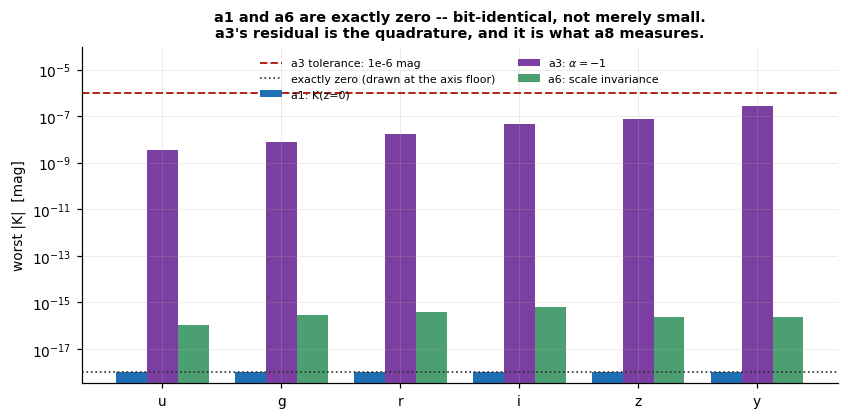

In [9]:
for nm in ("test_a1_zero_redshift_is_exactly_zero",
           "test_a3_alpha_minus_one_is_a_no_op_sed",
           "test_a6_scale_invariance"):
    show(*fork_test("TestRedshiftAnalytic." + nm))

bands6 = ["LSST_u", "LSST_g", "LSST_r", "LSST_i", "LSST_z", "LSST_y"]
lam_fine = np.geomspace(500.0, 60000.0, 200000)
a1, a3, a6 = [], [], []
for b in bands6:
    w_, t_ = fs.get_trans(b)
    a1.append(max(abs(k_correction(lam, planck_lam(lam, T), w_, t_, 0.0))
                  for T in (3500., 10000.)))
    a3.append(max(abs(k_correction(lam_fine, lam_fine ** -1.0, w_, t_, z))
                  for z in (0.02, 0.05, 0.2)))
    base = k_correction(lam, planck_lam(lam, 4500.), w_, t_, 0.05)
    a6.append(max(abs(k_correction(lam, c * planck_lam(lam, 4500.), w_, t_, 0.05) - base)
                  for c in (1e-12, 3.7, 1e15)))

fig, ax = plt.subplots(figsize=(7.6, 3.7), constrained_layout=True)
x = np.arange(len(bands6)); wdt = 0.26
FLOOR = 1e-18
for off, vals, lab, col, tol in (
        (-wdt, a1, "a1: K(z=0)", C["ours"], None),
        (0.0, a3, r"a3: $\alpha=-1$", C["alt"], 1e-6),
        (wdt, a6, "a6: scale invariance", C["smooth"], None)):
    ax.bar(x + off, [max(v, FLOOR) for v in vals], wdt, color=col, label=lab)
ax.axhline(1e-6, color=C["bad"], lw=1.3, ls="--", label="a3 tolerance: 1e-6 mag")
ax.axhline(FLOOR, color=C["truth"], lw=1.1, ls=":",
           label="exactly zero (drawn at the axis floor)")
ax.set_yscale("log"); ax.set_ylim(FLOOR / 3, 1e-4)
ax.set_xticks(x); ax.set_xticklabels([b.split("_")[-1] for b in bands6])
ax.set_ylabel("worst |K|  [mag]")
ax.set_title("a1 and a6 are exactly zero -- bit-identical, not merely small.\n"
             "a3's residual is the quadrature, and it is what a8 measures.")
ax.legend(fontsize=7.2, ncol=2, loc="upper center")
plt.show()

### R2.4 · `a5`, `a7`, `a8` — an independent route, composition, and convergence

**What is being tested.**

* **`a5` — the same physics by another road.** The implementation blueshifts the
  *filter* onto the rest-frame wavelength grid. This test instead redshifts the
  *spectrum* onto an observer-frame grid and integrates against the unshifted
  filter. The two share no code. They must agree.
* **`a7` — composition.** Redshifting by `z₁` and then by `z₂` must equal
  redshifting once by `(1+z₁)(1+z₂)−1`. Any stray `(1+z)` breaks this even when
  each individual value looks reasonable.
* **`a8` — convergence.** Halving the wavelength step must move the answer by
  less than `10⁻⁴` mag. This is what puts a number on "the residual in `a3` is
  the integrator, not the physics".

**Why they matter.** `a5` is the only test here that checks the *implementation
strategy* rather than the formula: if blueshifting the filter were subtly not
the same thing as redshifting the source, everything else would still pass.

✅  PASS
    ArtPop/tests/test_redshift.py::TestRedshiftAnalytic.test_a5_filter_shift_equivalence
✅  PASS
    ArtPop/tests/test_redshift.py::TestRedshiftAnalytic.test_a7_composition
✅  PASS
    ArtPop/tests/test_redshift.py::TestRedshiftAnalytic.test_a8_integrator_convergence


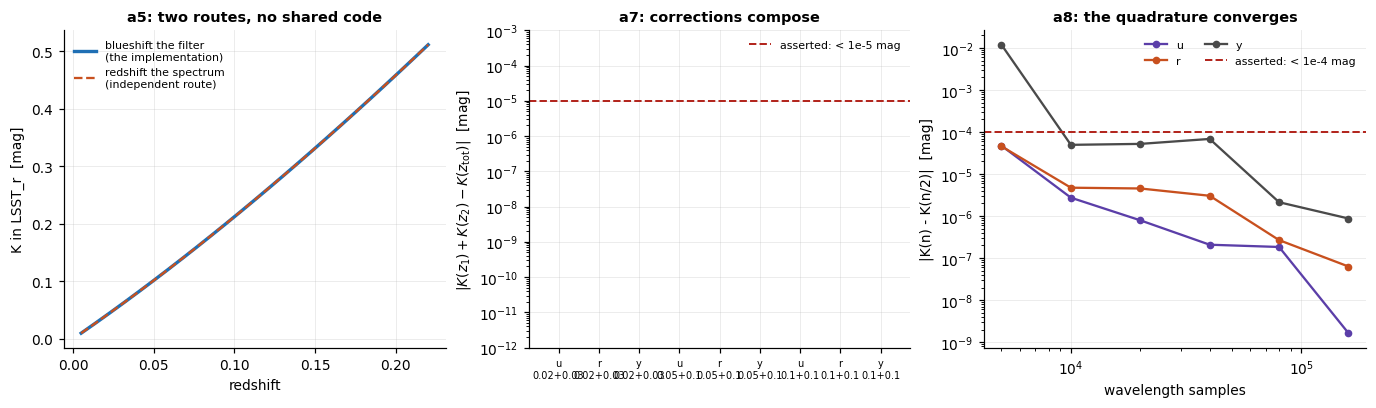

In [10]:
for nm in ("test_a5_filter_shift_equivalence", "test_a7_composition",
           "test_a8_integrator_convergence"):
    show(*fork_test("TestRedshiftAnalytic." + nm))

fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.6), constrained_layout=True)

# --- a5 -------------------------------------------------------------------
ax = axes[0]
sed = planck_lam(lam, 4000.)
den = np.dot(sed, band_weights(lam, tw, tt, 0.0))
zg = np.linspace(0.005, 0.22, 25)
ours = np.array([k_correction(lam, sed, tw, tt, z) for z in zg])
other = np.array([-2.5 * np.log10(
    np.dot(sed / (1 + z), band_weights(lam * (1 + z), tw, tt, 0.0)) / den)
    for z in zg])
ax.plot(zg, ours, "-", lw=2.2, color=C["ours"], label="blueshift the filter\n(the implementation)")
ax.plot(zg, other, "--", lw=1.5, color=C["theirs"], label="redshift the spectrum\n(independent route)")
ax.set_xlabel("redshift"); ax.set_ylabel(f"K in {band}  [mag]")
ax.set_title("a5: two routes, no shared code")
ax.legend(fontsize=7.2)

# --- a7 -------------------------------------------------------------------
ax = axes[1]
pairs = [(0.02, 0.03), (0.05, 0.10), (0.10, 0.10)]
lbl, err = [], []
for z1, z2 in pairs:
    for b in ("LSST_u", "LSST_r", "LSST_y"):
        w_, t_ = fs.get_trans(b)
        k1 = k_correction(lam, sed, w_, t_, z1)
        k2 = k_correction(lam * (1 + z1), sed / (1 + z1), w_, t_, z2)
        ktot = k_correction(lam, sed, w_, t_, (1 + z1) * (1 + z2) - 1)
        err.append(abs(k1 + k2 - ktot)); lbl.append(f"{b[-1]}\n{z1}+{z2}")
ax.bar(range(len(err)), np.maximum(err, 1e-12), 0.62, color=C["alt"])
ax.axhline(1e-5, color=C["bad"], lw=1.3, ls="--", label="asserted: < 1e-5 mag")
ax.set_yscale("log"); ax.set_ylim(1e-12, 1e-3)
ax.set_xticks(range(len(err))); ax.set_xticklabels(lbl, fontsize=6.4)
ax.set_ylabel(r"$|K(z_1)+K(z_2)-K(z_{\rm tot})|$  [mag]")
ax.set_title("a7: corrections compose")
ax.legend(fontsize=7.2)

# --- a8 -------------------------------------------------------------------
ax = axes[2]
ns = np.array([2500, 5000, 10000, 20000, 40000, 80000, 160000])
for b in ("LSST_u", "LSST_r", "LSST_y"):
    w_, t_ = fs.get_trans(b)
    ks = np.array([k_correction(np.geomspace(500., 60000., n),
                                np.geomspace(500., 60000., n) ** 0.0
                                * planck_lam(np.geomspace(500., 60000., n), 4000.),
                                w_, t_, 0.05) for n in ns])
    ax.plot(ns[1:], np.abs(np.diff(ks)), "o-", ms=4, lw=1.5, color=BANDC[b],
            label=b.split("_")[-1])
ax.axhline(1e-4, color=C["bad"], lw=1.3, ls="--", label="asserted: < 1e-4 mag")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("wavelength samples"); ax.set_ylabel("|K(n) - K(n/2)|  [mag]")
ax.set_title("a8: the quadrature converges")
ax.legend(fontsize=7.2, ncol=2)
plt.show()

---
# §R3 — The libraries, the grid, and the seams between them

A K-correction needs a spectrum for every star. The spectra have to come from
somewhere, and *which* somewhere turns out to be the single most consequential
decision in this work.

The first draft of the plan assumed any convenient library would do, on the
grounds that the correction depends only on spectral *shape* and not on
normalisation. That is backwards. Shape is exactly where libraries disagree —
different opacities, line lists and treatments of convection move the continuum
by tenths of a magnitude in the blue. Substituting a library therefore injects
precisely the systematic that computing the correction *differentially* exists
to cancel.

So the libraries used are **MIST's own**. MIST v2.5's bolometric corrections are
a composite:

| component | coverage | role here |
|---|---|---|
| **C3K** (ATLAS12 + SYNTHE) | 2 500–50 000 K, log g −1…5.5 | the production backend |
| **Tremblay+2011** pure-H white dwarfs | 1 500–140 000 K, log g 6.5…9.5 | the white-dwarf branch |
| blackbody | above 200 kK, and the log g 5.5–6.5 gap | the flagged fallback |
| cool carbon stars | the cool edge | never published — flagged, never extrapolated |

Two things follow that this section measures: **every backend switch has to be
recorded**, because a silent fallback is indistinguishable from a computed
answer; and **the seams between libraries are real steps**, so the useful
question is not whether they exist but how much the differential form suppresses
them.

*(A by-product settled while building this: C3K's wavelengths are **vacuum** and
Tremblay's are **air** — `HANDOFF_REDSHIFT.md` §1b had left that open. Measured
on the solar C3K node, nine strong lines sit at their vacuum wavelengths to
better than 0.3 × 10⁻⁴ fractional, against a 2.77 × 10⁻⁴ air offset. The loader
converts Tremblay and leaves C3K alone.)*

### R3.1 · `check_kgrid_backends` — nothing is served silently

**What is being tested.** Take a real 10 Gyr isochrone, correct it to
`z = 0.05`, and ask of every one of its 1 435 rows: which spectral library
actually supplied its spectrum? Then weight those rows by how much light they
carry, and by how much *fluctuation* signal they carry.

**Why it matters.** The blackbody fallback exists because there is a genuine gap
in MIST's composite between C3K's ceiling (log g 5.5) and Tremblay's floor
(log g 6.5), and a handful of post-AGB stars land in it. That is fine — as long
as it is *known*. A fallback that carried real flux would mean the correction
was being computed by an approximation nobody chose. The check fails if the
fallback carries more than 0.1% of the fluctuation weight.

**What the figure shows.** Left: the temperature-gravity plane, every isochrone
row coloured by which library served it, with the two library hulls drawn.
Right: the same rows counted three ways — by number, by light, and by
fluctuation weight. The white-dwarf branch is 19% of the rows and essentially
none of the signal.

✅  PASS
    1435 rows: C3K 1155 / Tremblay 274 / blackbody fallback 6; C3K carries >= 99.96% of the flux, the
    fallback <= 0.0005% of the f^2 (SBF) weight; 0 rows had [Fe/H] clipped


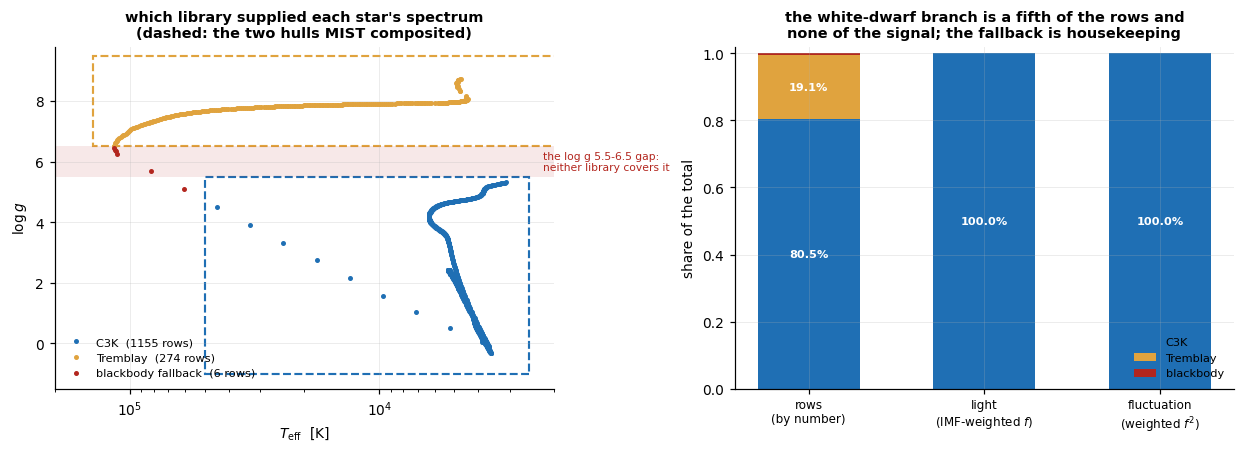

In [11]:
status, detail, d = RT["kgrid_backends"]
show(status, detail)

lt = np.array(d["log_teff"]); lg = np.array(d["log_g"]); src = np.array(d["source"])
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.0), constrained_layout=True)

ax = axes[0]
for code_, name in ((SOURCE_C3K, "C3K"), (SOURCE_WD, "Tremblay"),
                    (SOURCE_BB, "blackbody fallback")):
    m = src == code_
    ax.plot(10 ** lt[m], lg[m], ".", ms=4.5, color=BACKC[name.split()[0]],
            label=f"{name}  ({m.sum()} rows)")
from matplotlib.patches import Rectangle
ax.add_patch(Rectangle((2500, -1.0), 50000 - 2500, 6.5, fill=False,
                       ec=BACKC["C3K"], lw=1.4, ls="--"))
ax.add_patch(Rectangle((1500, 6.5), 140000 - 1500, 3.0, fill=False,
                       ec=BACKC["Tremblay"], lw=1.4, ls="--"))
ax.axhspan(5.5, 6.5, color=BACKC["blackbody"], alpha=0.10, lw=0)
ax.text(2.2e3, 6.0, "the log g 5.5-6.5 gap:\nneither library covers it",
        fontsize=7.0, color=BACKC["blackbody"], va="center")
ax.set_xscale("log"); ax.set_xlim(2e3, 2e5); ax.set_ylim(-1.5, 9.8)
ax.invert_xaxis()
ax.set_xlabel(r"$T_{\rm eff}$  [K]"); ax.set_ylabel(r"$\log g$")
ax.set_title("which library supplied each star's spectrum\n"
             "(dashed: the two hulls MIST composited)")
ax.legend(fontsize=7.4, loc="lower left")

ax = axes[1]
sh = d["shares"]["LSST_r"]
names = ["C3K", "Tremblay", "blackbody"]
counts = np.array([d["counts"][n] for n in names], dtype=float)
metrics = {
    "rows\n(by number)": counts / counts.sum(),
    "light\n(IMF-weighted $f$)": np.array([sh[n][0] for n in names]),
    "fluctuation\n(weighted $f^2$)": np.array([sh[n][1] for n in names]),
}
x = np.arange(len(metrics)); bottom = np.zeros(len(metrics))
for i, n in enumerate(names):
    vals = np.array([v[i] for v in metrics.values()])
    ax.bar(x, vals, 0.58, bottom=bottom, color=BACKC[n], label=n)
    for xi, (v, b0) in enumerate(zip(vals, bottom)):
        if v > 0.03:
            ax.text(xi, b0 + v / 2, f"{100 * v:.1f}%", ha="center", va="center",
                    fontsize=7.4, color="white", weight="bold")
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels(list(metrics), fontsize=7.8)
ax.set_ylim(0, 1.02); ax.set_ylabel("share of the total")
ax.set_title("the white-dwarf branch is a fifth of the rows and\n"
             "none of the signal; the fallback is housekeeping")
ax.legend(fontsize=7.4, loc="lower right")
plt.show()

### R3.2 · `test_b9_differential_form_suppresses_the_library_seam`

**What is being tested.** At the join between C3K and Tremblay — log g 5.5
versus 6.5 at the same temperature — the two libraries describe genuinely
different stars: one a metal-bearing atmosphere, the other a pure-hydrogen white
dwarf. Their absolute colours step across that boundary. The test measures how
big that step is in the raw photometry and how big it is in the *correction*.

**Why it matters.** This is the entire argument for computing the correction
differentially rather than regenerating magnitudes from scratch. The step in the
underlying photometry is 0.4–0.5 mag. If the correction inherited that, the seam
would be a 0.5 mag discontinuity in the middle of the corrected isochrone. Because
the correction is a *ratio of two integrals over the same spectrum*, most of the
library's idiosyncrasy cancels.

The step is real and is in MIST's own tables already: at log Teff = 3.17609 in
`bcl/feh+0.00_afe+0.0.LSST`, every row with log g ≤ 6.0 carries an identical
bolometric correction and log g = 6.5 jumps. This test does not pretend it away;
it measures the suppression.

✅  PASS
    ArtPop/tests/test_redshift.py::TestKCorrectionGrid.test_b9_differential_form_suppresses_the_library_
    seam


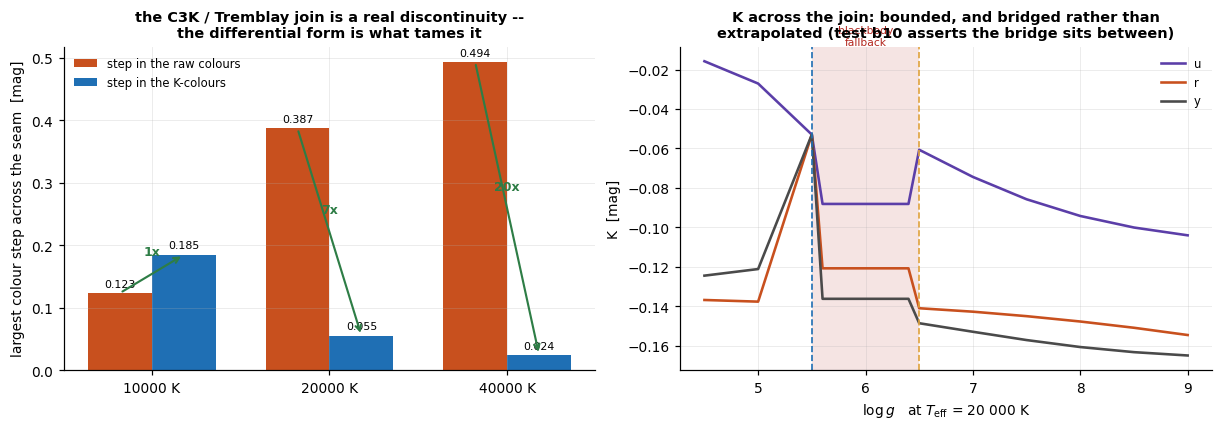

In [12]:
status, detail = fork_test("TestKCorrectionGrid.test_b9_differential_form_suppresses_the_library_seam")
show(status, detail)

c3k, wd = C3KLibrary(), TremblayWDLibrary()
lg_c, lt_c, cube = c3k.grid(-1.0)
lg_w, lt_w, fw = wd.grid()
gridL = KCorrectionGrid.cached("LSST", bands=list(BANDC))

def ab_mag(lm, fnu, b):
    w_ = band_weights(lm, *fs.get_trans(b), 0.0, flux_unit="f_nu")
    return -2.5 * np.log10(np.dot(fnu, w_) /
                           np.dot(np.full_like(np.asarray(lm, float), 3631e-23), w_))

teffs = [10000., 20000., 40000.]
step_mag, step_k = [], []
for T in teffs:
    it = int(np.argmin(abs(10 ** lt_c - T))); ig = int(np.argmin(abs(lg_c - 5.5)))
    jt = int(np.argmin(abs(10 ** lt_w - T))); jg = int(np.argmin(abs(lg_w - 6.5)))
    mc = [ab_mag(c3k.wave, cube[ig, it], b) for b in BANDC]
    mw = [ab_mag(wd.wave, fw[jg, jt], b) for b in BANDC]
    kc = gridL.interpolate(np.log10(T), 5.5, -1.0, 0.05)[0][0]
    kw = gridL.interpolate(np.log10(T), 6.5, -1.0, 0.05)[0][0]
    step_mag.append(max(abs((mc[i] - mc[i+1]) - (mw[i] - mw[i+1])) for i in range(5)))
    step_k.append(max(abs((kc[i] - kc[i+1]) - (kw[i] - kw[i+1])) for i in range(5)))

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8), constrained_layout=True)
ax = axes[0]
x = np.arange(len(teffs)); w_ = 0.36
ax.bar(x - w_/2, step_mag, w_, color=C["theirs"], label="step in the raw colours")
ax.bar(x + w_/2, step_k, w_, color=C["ours"], label="step in the K-colours")
for i, (a_, b_) in enumerate(zip(step_mag, step_k)):
    ax.text(i - w_/2, a_ + 0.01, f"{a_:.3f}", ha="center", fontsize=7.2)
    ax.text(i + w_/2, b_ + 0.01, f"{b_:.3f}", ha="center", fontsize=7.2)
    ax.annotate("", xy=(i + w_/2, b_), xytext=(i - w_/2, a_),
                arrowprops=dict(arrowstyle="->", color=C["ok"], lw=1.4))
    ax.text(i, (a_ + b_) / 2 + 0.03, f"{a_/b_:.0f}x", ha="center",
            fontsize=8.2, color=C["ok"], weight="bold")
ax.set_xticks(x); ax.set_xticklabels([f"{t:.0f} K" for t in teffs])
ax.set_ylabel("largest colour step across the seam  [mag]")
ax.set_title("the C3K / Tremblay join is a real discontinuity --\n"
             "the differential form is what tames it")
ax.legend(fontsize=7.6)

ax = axes[1]
lgs = np.linspace(4.5, 9.0, 46)
for b in ("LSST_u", "LSST_r", "LSST_y"):
    j = list(gridL.bands).index(b)
    ax.plot(lgs, [gridL.interpolate(np.log10(20000.), g, -1.0, 0.05)[0][0, j]
                  for g in lgs], "-", lw=1.7, color=BANDC[b],
            label=b.split("_")[-1])
ax.axvspan(5.5, 6.5, color=BACKC["blackbody"], alpha=0.12, lw=0)
ax.text(6.0, ax.get_ylim()[1] * 0.92, "blackbody\nfallback", ha="center",
        fontsize=7.0, color=BACKC["blackbody"])
ax.axvline(5.5, color=BACKC["C3K"], lw=1.1, ls="--")
ax.axvline(6.5, color=BACKC["Tremblay"], lw=1.1, ls="--")
ax.set_xlabel(r"$\log g$   at $T_{\rm eff}$ = 20 000 K"); ax.set_ylabel("K  [mag]")
ax.set_title("K across the join: bounded, and bridged rather than\n"
             "extrapolated (test b10 asserts the bridge sits between)")
ax.legend(fontsize=7.6)
plt.show()

### R3.3 · `test_b2` / `test_b3` — how K depends on temperature, measured not assumed

**What is being tested.** Two orderings. First, that a cool giant's correction
in the blue increases monotonically with redshift. Second, that at fixed
redshift cooler stars have larger corrections in the blue.

**Why it matters, and what changed.** `HANDOFF_REDSHIFT.md` claims the second
ordering "holds across the grid". **Measured, that is false in two bands.** In
`u` the correction falls from +0.47 at 3 500 K to a minimum near 5 000 K and then
climbs again to +0.55 by 8 000 K; in `z` it turns near 7 000 K. Both turns are a
spectral edge crossing the filter as it blueshifts — the Balmer jump at 3 646 Å
for `u`, the Paschen jump at 8 204 Å for `z`. `g`, `r`, `i` and `y` are monotone
throughout.

The test was rewritten to assert what is true — the ordering on the giant
branch, where all the light and all the fluctuation signal live — *and* to
assert that the two turns exist, because structure like this is exactly what a
single per-galaxy number cannot represent.

✅  PASS
    ArtPop/tests/test_redshift.py::TestKCorrectionGrid.test_b2_monotonic_in_redshift
✅  PASS
    ArtPop/tests/test_redshift.py::TestKCorrectionGrid.test_b3_k_orders_by_temperature_but_not_monotonic
    ally_everywhere


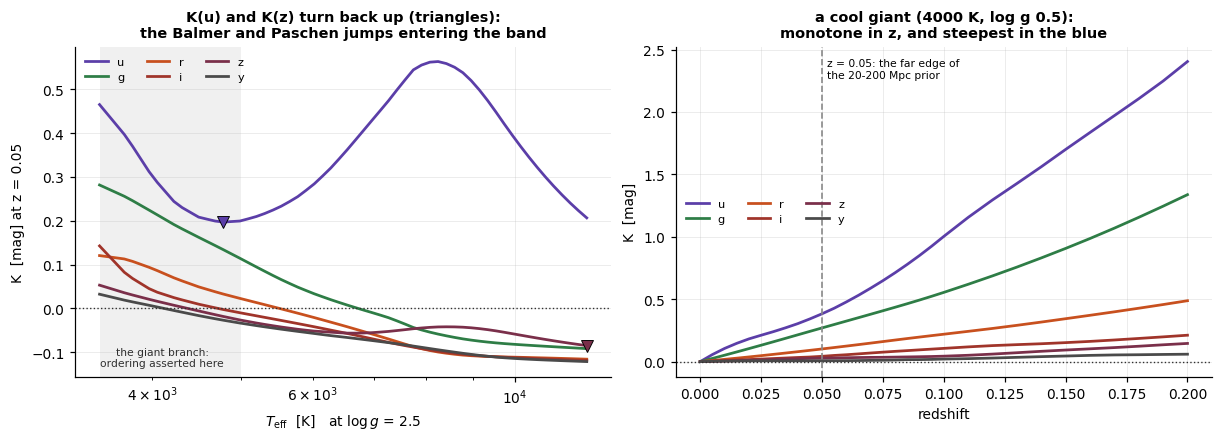

In [13]:
for nm in ("test_b2_monotonic_in_redshift",
           "test_b3_k_orders_by_temperature_but_not_monotonically_everywhere"):
    show(*fork_test("TestKCorrectionGrid." + nm))

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.9), constrained_layout=True)
ax = axes[0]
tgrid = np.geomspace(3500., 12000., 60)
for b in list(BANDC):
    j = list(gridL.bands).index(b)
    k = [gridL.interpolate(np.log10(t), 2.5, -1.0, 0.05)[0][0, j] for t in tgrid]
    ax.plot(tgrid, k, "-", lw=1.8, color=BANDC[b], label=b.split("_")[-1])
    if b in ("LSST_u", "LSST_z"):
        i = int(np.argmin(k))
        ax.plot(tgrid[i], k[i], "v", ms=8, color=BANDC[b], mec="k", mew=0.6)
ax.axhline(0, color=C["truth"], lw=0.9, ls=":")
ax.axvspan(3500, 5000, color=C["muted"], alpha=0.12, lw=0)
ax.text(4100, ax.get_ylim()[0] * 0.85, "the giant branch:\nordering asserted here",
        fontsize=7.0, ha="center", color=C["truth"])
ax.set_xscale("log")
ax.set_xlabel(r"$T_{\rm eff}$  [K]   at $\log g$ = 2.5"); ax.set_ylabel("K  [mag] at z = 0.05")
ax.set_title("K(u) and K(z) turn back up (triangles):\n"
             "the Balmer and Paschen jumps entering the band")
ax.legend(fontsize=7.4, ncol=3)

ax = axes[1]
zg2 = np.linspace(0, 0.2, 41)
for b in list(BANDC):
    j = list(gridL.bands).index(b)
    ax.plot(zg2, [gridL.interpolate(np.log10(4000.), 0.5, -1.0, z)[0][0, j]
                  for z in zg2], "-", lw=1.8, color=BANDC[b],
            label=b.split("_")[-1])
ax.axhline(0, color=C["truth"], lw=0.9, ls=":")
ax.axvline(0.05, color=C["muted"], lw=1.1, ls="--")
ax.text(0.052, ax.get_ylim()[1] * 0.9, "z = 0.05: the far edge of\nthe 20-200 Mpc prior",
        fontsize=7.0)
ax.set_xlabel("redshift"); ax.set_ylabel("K  [mag]")
ax.set_title("a cool giant (4000 K, log g 0.5):\nmonotone in z, and steepest in the blue")
ax.legend(fontsize=7.4, ncol=3)
plt.show()

### R3.4 · `check_resolution_systematic` — what the library's own choices cost

**What is being tested.** The same correction computed from C3K at `R = 3000`
and at `R = 100`, and from `[α/Fe] = 0` versus `[α/Fe] = +0.4`, node by node
over the whole 13 × 14 × 80 grid.

**Why it matters.** These are the two knobs the library itself has, and neither
is a physical property of the star being modelled. A broadband correction ought
to be nearly blind to both — the filter integrates over thousands of lines. This
check puts a number on "nearly", and that number is what makes it legitimate to
call the correction well determined.

**This is recorded, not asserted.** There is no pass/fail threshold, because
there is no principled value to pick; the point is to have measured it. And the
resolution figure is an **upper bound**: `c3k_lr` samples the near-infrared at
`R = 100`, coarser than the `i` and `y` filter edges, so part of what it shows is
the low-resolution grid failing to resolve the filter rather than a real
disagreement about the spectrum. Production uses `c3k_hr`.

✅  PASS
    |K(R=3000) - K(R=100)| at z=0.05, median over the whole 13 x 14 x 80 grid: u=0.0002  g=0.0001
    r=0.0001  i=0.0099  z=0.0011  y=0.0116
      |K([a/Fe]=0) - K([a/Fe]=+0.4)| at R=100, same statistic:   u=0.0004  g=0.0000  r=0.0000  i=0.0000
    z=0.0001  y=0.0000
      recorded as a systematic, not asserted. The resolution number is an UPPER bound: c3k_lr samples
    the NIR at R = 100, coarser than the i and y filter edges, so part of what it measures is the low-
    resolution grid's own edge sampling rather than a physical library difference. Production uses
    c3k_hr.


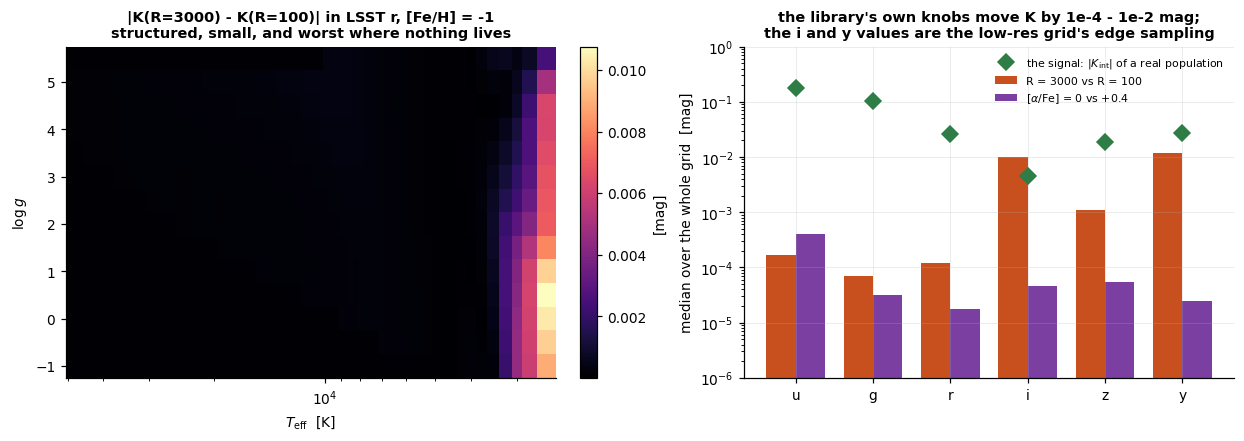

In [14]:
status, detail, d = RT["resolution_systematic"]
show(status, detail)

iz = d["i_z"]; bands6 = d["bands"]
res_med = np.array(d["res_median"])[iz]; afe_med = np.array(d["afe_median"])[iz]
fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.9), constrained_layout=True)

ax = axes[0]
m = np.array(d["res_map_r"])[6]                      # [Fe/H] = -1.0 slice
im = ax.pcolormesh(10 ** np.array(d["logt"]), np.array(d["logg"]), m,
                   cmap="magma", shading="nearest")
ax.set_xscale("log"); ax.invert_xaxis()
ax.set_xlabel(r"$T_{\rm eff}$  [K]"); ax.set_ylabel(r"$\log g$")
ax.set_title("|K(R=3000) - K(R=100)| in LSST r, [Fe/H] = -1\n"
             "structured, small, and worst where nothing lives")
ax.grid(False)
plt.colorbar(im, ax=ax, label="[mag]")

ax = axes[1]
x = np.arange(len(bands6)); w_ = 0.38
signal = [abs(r[1]) for r in RT["error_budget"][2]["rows"]]
ax.bar(x - w_/2, res_med, w_, color=C["theirs"], label="R = 3000 vs R = 100")
ax.bar(x + w_/2, np.maximum(afe_med, 1e-6), w_, color=C["alt"],
       label=r"[$\alpha$/Fe] = 0 vs +0.4")
ax.plot(x, signal, "D", ms=7, color=C["ok"],
        label=r"the signal: $|K_{\rm int}|$ of a real population")
ax.set_yscale("log"); ax.set_ylim(1e-6, 1)
ax.set_xticks(x); ax.set_xticklabels([b.split("_")[-1] for b in bands6])
ax.set_ylabel("median over the whole grid  [mag]")
ax.set_title("the library's own knobs move K by 1e-4 - 1e-2 mag;\n"
             "the i and y values are the low-res grid's edge sampling")
ax.legend(fontsize=7.2)
plt.show()

### R3.5 · `check_feh_lookup_sensitivity` — a small decision, measured rather than waved through

**What is being tested.** MIST isochrones carry a per-row `[Fe/H]` column that
drifts away from the value on the filename — it reaches +0.042 even in the
`feh_p0.00` file — because it is the star's *actual* surface abundance after
diffusion and dredge-up, not the label of the model set. The implementation uses
that per-row value as the spectral-library lookup key. This measures what that
choice is worth against using the requested scalar.

**Why it matters.** Not because the effect is large — it is about a thousandth
of a magnitude — but because the alternative was to assume it was small. A
recorded measurement is the difference between a decision and a guess.

✅  PASS
    per-row vs scalar [Fe/H] lookup: max |dK| = u=0.0013  g=0.0006  r=0.0004  i=0.0007  z=0.0002
    y=0.0000 mag (worst 0.0013); flux-weighted it is u=-0.0002  g=-0.0002  r=+0.0000  i=+0.0000
    z=+0.0000  y=+0.0000
      (the per-row column is used; this records what that choice is worth)


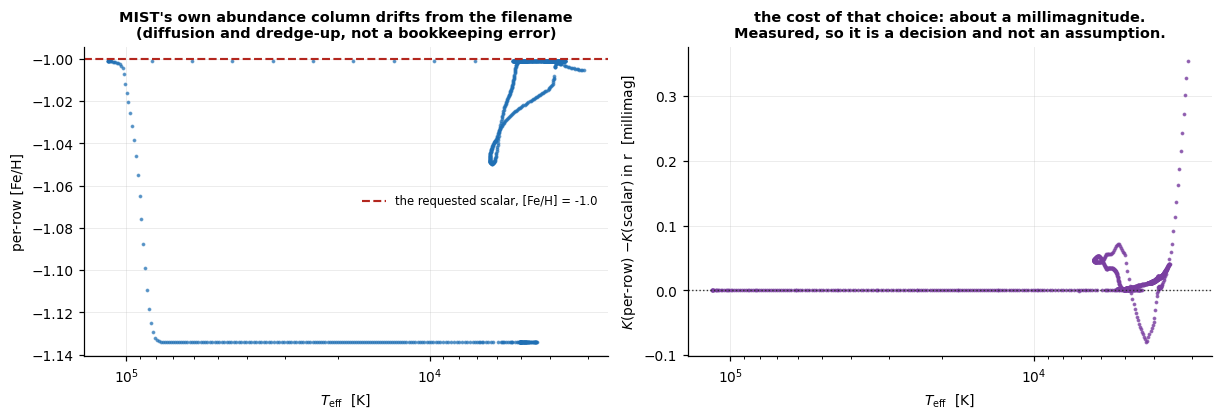

In [15]:
status, detail, d = RT["feh_lookup_sensitivity"]
show(status, detail)

lt = np.array(d["log_teff"]); fe = np.array(d["feh_star"]); dk = np.array(d["delta_r"])
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.7), constrained_layout=True)

ax = axes[0]
ax.plot(10 ** lt, fe, ".", ms=3, color=C["ours"], alpha=0.6)
ax.axhline(d["feh"], color=C["bad"], lw=1.4, ls="--",
           label=f"the requested scalar, [Fe/H] = {d['feh']}")
ax.set_xscale("log"); ax.invert_xaxis()
ax.set_xlabel(r"$T_{\rm eff}$  [K]"); ax.set_ylabel(r"per-row [Fe/H]")
ax.set_title("MIST's own abundance column drifts from the filename\n"
             "(diffusion and dredge-up, not a bookkeeping error)")
ax.legend(fontsize=7.6)

ax = axes[1]
ax.plot(10 ** lt, dk * 1e3, ".", ms=3, color=C["alt"], alpha=0.7)
ax.axhline(0, color=C["truth"], lw=0.9, ls=":")
ax.set_xscale("log"); ax.invert_xaxis()
ax.set_xlabel(r"$T_{\rm eff}$  [K]")
ax.set_ylabel(r"$K$(per-row) $- K$(scalar) in r  [millimag]")
ax.set_title("the cost of that choice: about a millimagnitude.\n"
             "Measured, so it is a decision and not an assumption.")
plt.show()

### R3.6 · The grid's mechanics — `b1`, `b4`, `b5`, `b5b`, `b6`, `b7`, `b8`, `b10`

These eight assert plumbing rather than physics, so they get a table rather than
eight figures — following the same convention `visualize_tests.ipynb` uses for
its excluded checks, where the omission is stated rather than left as an
oversight. Each one guards a way the correction could be quietly wrong:

| test | what would go unnoticed without it |
|---|---|
| `b1` | interpolation that does not reproduce its own grid nodes |
| `b4` | a cached grid that reloads as something slightly different |
| `b5` | a star outside both libraries served by an unflagged extrapolation |
| `b5b` | `[Fe/H]` below C3K's floor extrapolated instead of clipped and flagged |
| `b6` | a blueshifted filter running off the blue end of the library, silently integrating zeros |
| `b7` | the `z = 0` slice being *nearly* zero instead of exactly zero |
| `b8` | a redshift beyond the grid extrapolated instead of refused |
| `b10` | the blackbody fallback landing somewhere unrelated to its neighbours |

The one figure worth drawing is the validity map: where on the
temperature-gravity plane each backend is used, and where the fallback flag is
raised.

  ✅ PASS  test_b1_interpolation_at_a_node_returns_the_node             node value reproduced
  ✅ PASS  test_b4_save_load_round_trip_is_bitwise                      cache round-trips bit for bit
  ✅ PASS  test_b5_out_of_hull_is_flagged_never_extrapolated            every backend switch recorded
  ✅ PASS  test_b5b_feh_below_the_library_floor_is_clipped_and_flagged  [Fe/H] < -2.5 clipped + flagged
  ✅ PASS  test_b6_library_covers_the_blueshifted_filters               C3K's blue edge is 100 A; nothing runs off
  ✅ PASS  test_b7_redshift_zero_slice_is_identically_zero              exactly 0.0, not merely small
  ✅ PASS  test_b8_redshift_outside_the_grid_raises                     refuses rather than extrapolates
  ✅ PASS  test_b10_blackbody_bridges_the_log_g_gap                     fallback sits between its neighbours


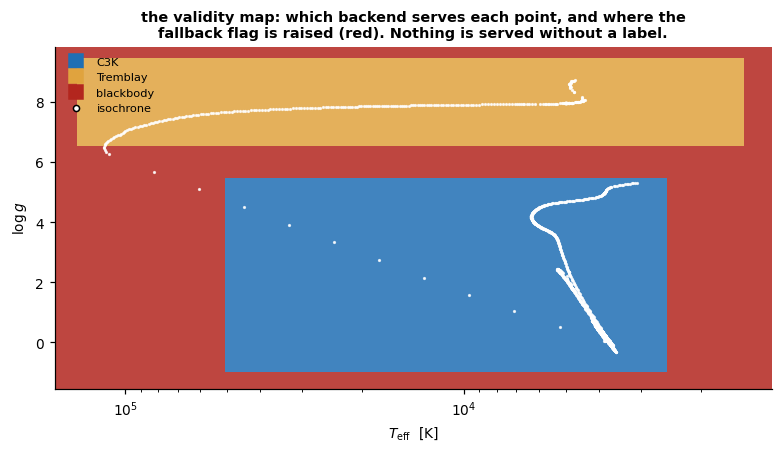

In [16]:
grid_tests = ["test_b1_interpolation_at_a_node_returns_the_node",
              "test_b4_save_load_round_trip_is_bitwise",
              "test_b5_out_of_hull_is_flagged_never_extrapolated",
              "test_b5b_feh_below_the_library_floor_is_clipped_and_flagged",
              "test_b6_library_covers_the_blueshifted_filters",
              "test_b7_redshift_zero_slice_is_identically_zero",
              "test_b8_redshift_outside_the_grid_raises",
              "test_b10_blackbody_bridges_the_log_g_gap"]
notes = {
    "test_b1_interpolation_at_a_node_returns_the_node": "node value reproduced",
    "test_b4_save_load_round_trip_is_bitwise": "cache round-trips bit for bit",
    "test_b5_out_of_hull_is_flagged_never_extrapolated": "every backend switch recorded",
    "test_b5b_feh_below_the_library_floor_is_clipped_and_flagged": "[Fe/H] < -2.5 clipped + flagged",
    "test_b6_library_covers_the_blueshifted_filters": "C3K's blue edge is 100 A; nothing runs off",
    "test_b7_redshift_zero_slice_is_identically_zero": "exactly 0.0, not merely small",
    "test_b8_redshift_outside_the_grid_raises": "refuses rather than extrapolates",
    "test_b10_blackbody_bridges_the_log_g_gap": "fallback sits between its neighbours",
}
verdict_table(grid_tests, {k: FORK.get("TestKCorrectionGrid." + k, ("SKIP", ""))
                           for k in grid_tests}, notes)

TT, GG = np.meshgrid(np.linspace(3.1, 5.2, 130), np.linspace(-1.5, 9.8, 120))
_, info = gridL.interpolate(TT.ravel(), GG.ravel(), -1.0, 0.05)
S = np.array(info["source"]).reshape(TT.shape)
fig, ax = plt.subplots(figsize=(7.0, 4.0), constrained_layout=True)
cmap = mcolors.ListedColormap([BACKC["C3K"], BACKC["Tremblay"], BACKC["blackbody"]])
ax.pcolormesh(10 ** TT, GG, S, cmap=cmap, vmin=-0.5, vmax=2.5, shading="auto",
              alpha=0.85)
d0 = RT["kgrid_backends"][2]
ax.plot(10 ** np.array(d0["log_teff"]), np.array(d0["log_g"]), ".", ms=2.2,
        color="w", alpha=0.8, label="a real 10 Gyr isochrone")
ax.set_xscale("log"); ax.invert_xaxis(); ax.grid(False)
ax.set_xlabel(r"$T_{\rm eff}$  [K]"); ax.set_ylabel(r"$\log g$")
ax.set_title("the validity map: which backend serves each point, and where the\n"
             "fallback flag is raised (red). Nothing is served without a label.")
handles = [plt.Line2D([], [], marker="s", ls="", ms=9, color=BACKC[n], label=n)
           for n in ("C3K", "Tremblay", "blackbody")]
ax.legend(handles=handles + [plt.Line2D([], [], marker=".", ls="", ms=8,
                                        color="w", mec="k", label="isochrone")],
          fontsize=7.4, loc="upper left")
plt.show()

---
# §R4 — Integration: does the rest of ArtPop pick it up correctly?

The correction is applied in exactly one place: to the isochrone's magnitude
columns, at construction. That is a deliberate architectural choice and it is
what makes most of this section true by construction rather than by care.

Everything downstream reads those columns — the integrated magnitudes, the
sampled stars' absolute magnitudes, the surface-brightness fluctuation moments,
and the comparison against a magnitude limit. In particular the *second* moment
`Σ n f²` is built as `10^(−0.8 m)` from the same column that gives the first
moment `10^(−0.4 m)`. So it picks up `10^(−0.8 K)` automatically, which is the
right answer and the one that is easiest to get wrong when the correction is
bolted on later.

These tests exist because "true by construction" is a claim about the code, not
a substitute for checking it.

### R4.1 · `check_redshift_zero_noop` — the regression gate

**What is being tested.** Build everything twice — isochrone, population,
rendered image — once with no redshift argument at all and once with
`redshift=0.0` explicitly, and demand the results are **bit-identical**, using
`np.array_equal` rather than a tolerance.

**Why it matters.** This is the gate for the whole change. Every parameter added
here defaults to today's behaviour, so a single altered value means the additive
contract has been broken and every previously rendered image is now
irreproducible. A tolerance would hide exactly the drift this exists to catch.

It is achievable rather than merely approachable because of how the integral is
written: at `z = 0` with no dust, its numerator and denominator are computed by
the same code with the same arguments, so they are bit-identical and their ratio
is exactly `1.0`.

✅  PASS
    redshift=0.0 is bit-identical to stock across 6 magnitude columns, 5 population quantities and a
    101x101 rendered image (1459 stars)


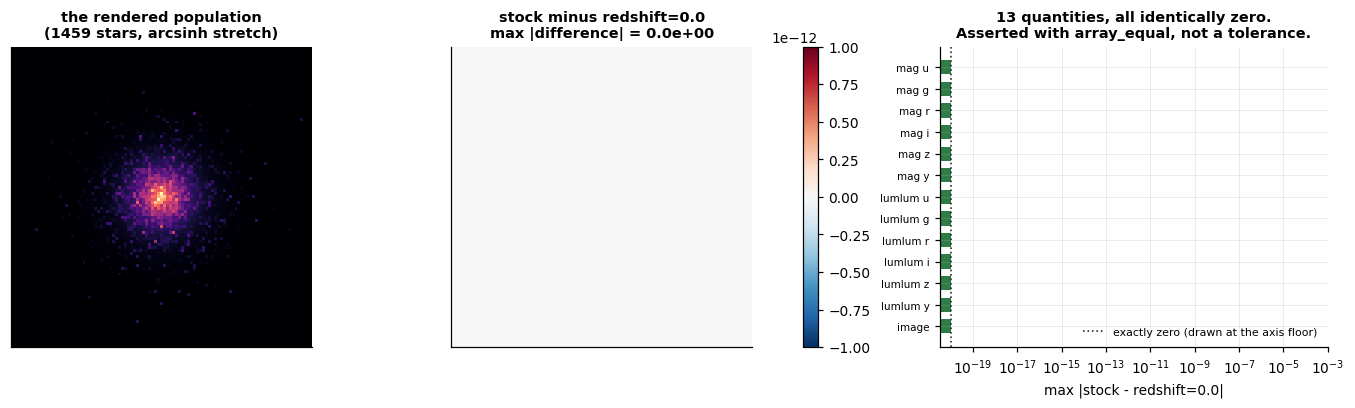

In [17]:
status, detail, d = RT["redshift_zero_noop"]
show(status, detail)

fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.6), constrained_layout=True)
img = np.array(d["img"]); dif = np.array(d["img_diff"])

ax = axes[0]
im = ax.imshow(np.arcsinh(img / np.percentile(img, 99.5)), cmap="magma")
ax.set_title(f"the rendered population\n({d['n_stars']} stars, arcsinh stretch)")
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

ax = axes[1]
im = ax.imshow(dif, cmap="RdBu_r", vmin=-1e-12, vmax=1e-12)
ax.set_title(f"stock minus redshift=0.0\nmax |difference| = {d['max_pixel_diff']:.1e}")
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[2]
items = ([(f"mag {k.split('_')[-1]}", v) for k, v in d["mag_diff"].items()]
         + [(f"lumlum {k.split('_')[-1]}", v) for k, v in d["lumlum_diff"].items()]
         + [("image", d["max_pixel_diff"])])
FLOOR = 1e-20
ax.barh(range(len(items)), [max(v, FLOOR) for _, v in items], 0.66,
        color=[C["ok"] if v == 0 else C["bad"] for _, v in items])
ax.axvline(FLOOR, color=C["truth"], lw=1.1, ls=":",
           label="exactly zero (drawn at the axis floor)")
ax.set_xscale("log"); ax.set_xlim(FLOOR / 3, 1e-3)
ax.set_yticks(range(len(items)))
ax.set_yticklabels([k for k, _ in items], fontsize=6.8)
ax.invert_yaxis()
ax.set_xlabel("max |stock - redshift=0.0|")
ax.set_title("13 quantities, all identically zero.\n"
             "Asserted with array_equal, not a tolerance.")
ax.legend(fontsize=7.2, loc="lower right")
plt.show()

### R4.2 · `test_c5` — the second moment carries `10^(−0.8 K)`, not `10^(−0.4 K)`

**What is being tested.** The smooth component of a magnitude-limited population
carries two analytic sums: a first moment `Σ n f` that becomes its total flux,
and a second moment `Σ n f²` that becomes its surface-brightness fluctuation
amplitude. The correction enters the second one *squared*. This test recomputes
that sum independently and also computes what the wrong power would give.

**Why it matters.** This is the single most dangerous place in the whole change,
and the repo already knows the failure mode in as many words — from
`check_sbf_moments_vs_artpop`: *"getting a power of the distance wrong there is a
pure multiplicative error on the injected amplitude that no shape or flux test
would notice."* Exactly the same is true of a power of the correction. Every
flux-conservation test, every image comparison, every colour check would pass
with `10^(−0.4 K)` in place of `10^(−0.8 K)`, and the injected fluctuation
amplitude would be wrong.

Applying the correction at the isochrone makes both powers right automatically.
The test is here anyway, and it deliberately checks that the two candidate
answers are far apart — otherwise it would prove nothing.

✅  PASS
    ArtPop/tests/test_redshift.py::TestRedshiftIntegration.test_c5_second_moment_carries_ten_to_the_minu
    s_point_eight_k


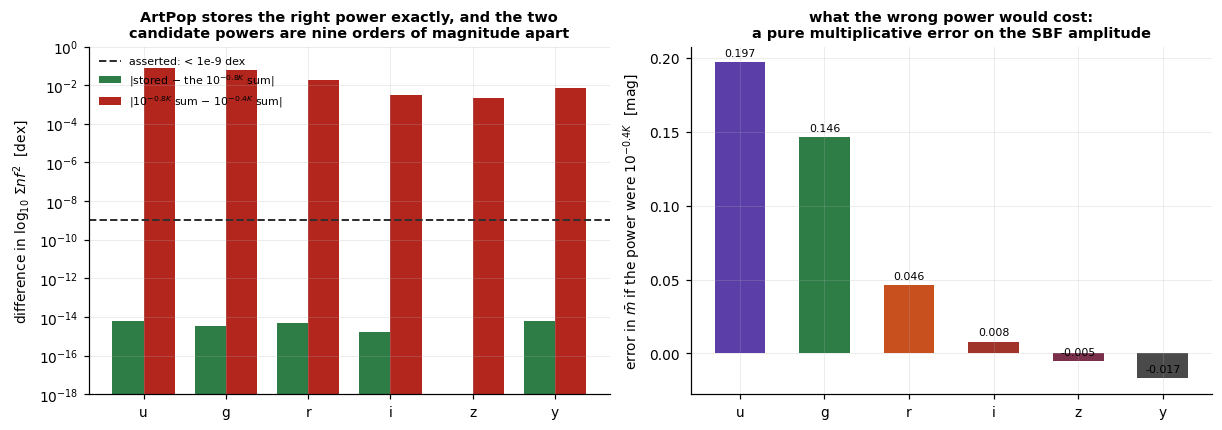

In [18]:
show(*fork_test("TestRedshiftIntegration.test_c5_second_moment_carries_ten_to_the_minus_point_eight_k"))

import pickle
from astropy.table import Table
from astropy import units as u
from artpop.stars import Isochrone, SSP
from artpop import data_dir

with open(os.path.join(data_dir, "feh_m1.00_vvcrit0.4_LSST_10gyr_test_iso.pkl"), "rb") as f:
    _t = Table(pickle.load(f))
F6 = list(BANDC)
_lt = np.asarray(_t["log_Teff"], float); _lg = np.asarray(_t["log_g"], float)
_fe = np.asarray(_t["[Fe/H]"], float)
_dk, _ = gridL.offsets(_lt, _lg, _fe, 0.05, bands=F6)
iso0 = Isochrone(mini=_t["initial_mass"], mact=_t["star_mass"],
                 mags=Table({b: np.asarray(_t[b], float) for b in F6}),
                 log_L=_t["log_L"], log_Teff=_lt, log_g=_lg, feh=_fe)
isoz = Isochrone(mini=_t["initial_mass"], mact=_t["star_mass"],
                 mags=Table({b: np.asarray(_t[b], float) + _dk[b] for b in F6}),
                 log_L=_t["log_L"], log_Teff=_lt, log_g=_lg, feh=_fe, redshift=0.05)
_band = "LSST_i"
_tip = float(np.asarray(iso0.mag_table[_band]).min() + 5 * np.log10(10e6) - 5)
ssp = SSP(isoz, total_mass=2e5, distance=10 * u.Mpc, mag_limit=_tip + 2.0,
          mag_limit_band=_band, random_state=42)
w_, bright = ssp._lf_row_split(); faint = ~bright
log_dddd = 4 * np.log10((10 * u.pc).to("cm").value)

rows = []
for b in F6:
    mz = np.asarray(isoz.mag_table[b], float); m0 = np.asarray(iso0.mag_table[b], float)
    right = ssp.n_total_expected * np.sum(w_[faint] * 10 ** (-0.8 * mz[faint]))
    wrong = ssp.n_total_expected * np.sum(w_[faint] * 10 ** (-0.4 * mz[faint])
                                          * 10 ** (-0.4 * m0[faint]))
    stored = ssp._integrated_log_lumlum[b] - log_dddd
    rows.append((b, abs(stored - np.log10(right)),
                 abs(np.log10(right) - np.log10(wrong)),
                 -2.5 * (np.log10(right) - np.log10(wrong))))

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8), constrained_layout=True)
ax = axes[0]
x = np.arange(len(rows)); w2 = 0.38
ax.bar(x - w2/2, [max(r[1], 1e-18) for r in rows], w2, color=C["ok"],
       label=r"|stored $-$ the $10^{-0.8K}$ sum|")
ax.bar(x + w2/2, [r[2] for r in rows], w2, color=C["bad"],
       label=r"|$10^{-0.8K}$ sum $-$ $10^{-0.4K}$ sum|")
ax.axhline(1e-9, color=C["truth"], lw=1.3, ls="--", label="asserted: < 1e-9 dex")
ax.set_yscale("log"); ax.set_ylim(1e-18, 1)
ax.set_xticks(x); ax.set_xticklabels([r[0].split("_")[-1] for r in rows])
ax.set_ylabel(r"difference in $\log_{10}\,\Sigma n f^2$  [dex]")
ax.set_title("ArtPop stores the right power exactly, and the two\n"
             "candidate powers are nine orders of magnitude apart")
ax.legend(fontsize=7.2)

ax = axes[1]
ax.bar(x, [r[3] for r in rows], 0.6, color=[BANDC[r[0]] for r in rows])
for i, r in enumerate(rows):
    ax.text(i, r[3] + 0.004, f"{r[3]:.3f}", ha="center", fontsize=7.2)
ax.set_xticks(x); ax.set_xticklabels([r[0].split("_")[-1] for r in rows])
ax.set_ylabel(r"error in $\bar m$ if the power were $10^{-0.4K}$  [mag]")
ax.set_title("what the wrong power would cost:\na pure multiplicative error on the SBF amplitude")
plt.show()

### R4.3 · `test_c10` — the magnitude limit moves, and the split stays exact

**What is being tested.** ArtPop renders bright stars individually and folds
faint ones into a smooth analytic component, splitting them at `mag_limit`. The
correction changes every star's magnitude, so some rows cross that boundary.
This test checks that they do — and that the two sides remain **exact
complements** afterwards.

**Why it matters.** `check_sbf_split_invariance` in the ALVISS suite depends on
those two sets partitioning the isochrone exactly. If one side were computed
with the correction applied and the other without, some rows would be counted
twice and others not at all, the total flux would still look right, and the
fluctuation amplitude would silently drift. Applying the correction to the
isochrone — before anything compares against the limit — means both sides see
corrected magnitudes and the complement holds by construction.

✅  PASS
    ArtPop/tests/test_redshift.py::TestRedshiftIntegration.test_c10_mag_limit_split_moves_and_stays_an_e
    xact_complement


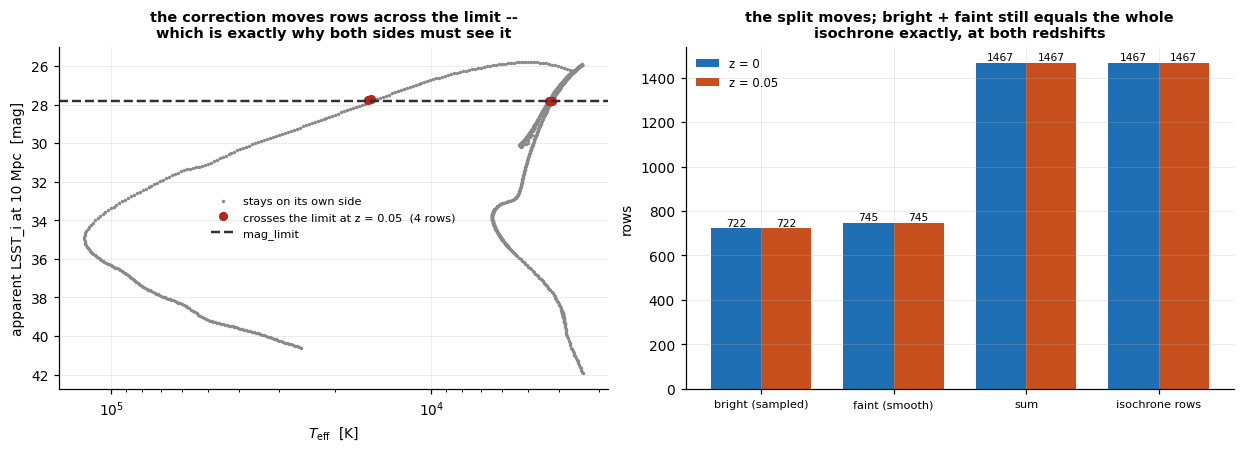

In [19]:
show(*fork_test("TestRedshiftIntegration.test_c10_mag_limit_split_moves_and_stays_an_exact_complement"))

dm = 5 * np.log10(10e6) - 5
lim = _tip + 2.0
a = SSP(iso0, total_mass=2e5, distance=10 * u.Mpc, mag_limit=lim,
        mag_limit_band=_band, random_state=42)
b = SSP(isoz, total_mass=2e5, distance=10 * u.Mpc, mag_limit=lim,
        mag_limit_band=_band, random_state=42)
_, br_a = a._lf_row_split(); _, br_b = b._lf_row_split()
m0 = np.asarray(iso0.mag_table[_band], float) + dm
mz = np.asarray(isoz.mag_table[_band], float) + dm
moved = br_a != br_b

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.0), constrained_layout=True)
ax = axes[0]
ax.plot(10 ** _lt[~moved], m0[~moved], ".", ms=2.5, color=C["muted"],
        label="stays on its own side")
for i in np.flatnonzero(moved):
    ax.plot([10 ** _lt[i]] * 2, [m0[i], mz[i]], "-", lw=1.0, color=C["bad"])
ax.plot(10 ** _lt[moved], mz[moved], "o", ms=5, color=C["bad"],
        label=f"crosses the limit at z = 0.05  ({moved.sum()} rows)")
ax.axhline(lim, color=C["truth"], lw=1.6, ls="--", label="mag_limit")
ax.set_xscale("log"); ax.invert_xaxis(); ax.invert_yaxis()
ax.set_xlabel(r"$T_{\rm eff}$  [K]")
ax.set_ylabel(f"apparent {_band} at 10 Mpc  [mag]")
ax.set_title("the correction moves rows across the limit --\n"
             "which is exactly why both sides must see it")
ax.legend(fontsize=7.4)

ax = axes[1]
labels = ["bright (sampled)", "faint (smooth)", "sum", "isochrone rows"]
za = [br_a.sum(), (~br_a).sum(), br_a.sum() + (~br_a).sum(), br_a.size]
zb = [br_b.sum(), (~br_b).sum(), br_b.sum() + (~br_b).sum(), br_b.size]
x = np.arange(4); w2 = 0.38
ax.bar(x - w2/2, za, w2, color=C["ours"], label="z = 0")
ax.bar(x + w2/2, zb, w2, color=C["theirs"], label="z = 0.05")
for i, (p, q) in enumerate(zip(za, zb)):
    ax.text(i - w2/2, p + 12, str(p), ha="center", fontsize=7.0)
    ax.text(i + w2/2, q + 12, str(q), ha="center", fontsize=7.0)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=7.4)
ax.set_ylabel("rows")
ax.set_title("the split moves; bright + faint still equals the whole\n"
             "isochrone exactly, at both redshifts")
ax.legend(fontsize=7.6)
plt.show()

### R4.4 · The remaining integration tests

Six more, each guarding a way the correction could leak into or out of the wrong
place. They are tabulated rather than drawn: their content is an equality, and
`§R6` already draws the geometry ones.

| test | the claim |
|---|---|
| `c1` (MIST) | `MISTIsochrone(redshift=0.0)` is byte-for-byte stock |
| `c2` | at `z > 0` the columns are exactly *stock + the interpolated correction* — differential by construction, so MIST's `z = 0` calibration survives untouched |
| `c2b` | `set_redshift` re-corrects the **rest-frame** columns, not the already-corrected ones. Correcting a correction would be wrong by the old offset and would look almost right |
| `c3` | with the same stars, the total flux moves by exactly the flux-weighted correction over those stars |
| `c6` | the correction does not move with distance, and the distance modulus does not move with redshift — the independence the whole design rests on |
| `c9` | adding two populations corrected to different redshifts raises rather than silently averaging them |
| `c11` | `set_redshift` **refuses** on a population that has a smooth component, because both the row split and the analytic sums depend on `z` and a stale one would be invisible |

In [20]:
integration = [
    ("TestRedshiftMIST.test_c1_mist_zero_redshift_is_bit_identical",
     "redshift=0.0 is byte-for-byte stock"),
    ("TestRedshiftMIST.test_c2_columns_equal_stock_plus_the_interpolated_correction",
     "columns = stock + correction, exactly"),
    ("TestRedshiftMIST.test_c2b_set_redshift_restores_before_reapplying",
     "re-corrects the rest frame, not the corrected frame"),
    ("TestRedshiftIntegration.test_c3_total_flux_moves_by_the_k_of_the_stars_it_contains",
     "same stars -> exact flux-weighted correction"),
    ("TestRedshiftIntegration.test_c4_sbf_k_is_not_the_integrated_k",
     "the f^2 weighting pushes mbar further, in every band"),
    ("TestRedshiftIntegration.test_c6_distance_and_redshift_are_independent",
     "K is invariant in D_L; dist_mod is invariant in z"),
    ("TestRedshiftIntegration.test_c9_composite_rejects_a_redshift_mismatch",
     "mismatched redshifts raise"),
    ("TestRedshiftIntegration.test_c11_set_redshift_refuses_a_stale_smooth_component",
     "refuses where it would leave a stale smooth component"),
]
names = [n for n, _ in integration]
verdict_table([n.split(".")[-1] for n in names],
              {n.split(".")[-1]: FORK.get(n, ("SKIP", "")) for n in names},
              {n.split(".")[-1]: t for n, t in integration})

  ✅ PASS  test_c1_mist_zero_redshift_is_bit_identical                   redshift=0.0 is byte-for-byte stock
  ✅ PASS  test_c2_columns_equal_stock_plus_the_interpolated_correction  columns = stock + correction, exactly
  ✅ PASS  test_c2b_set_redshift_restores_before_reapplying              re-corrects the rest frame, not the corrected frame
  ✅ PASS  test_c3_total_flux_moves_by_the_k_of_the_stars_it_contains    same stars -> exact flux-weighted correction
  ✅ PASS  test_c4_sbf_k_is_not_the_integrated_k                         the f^2 weighting pushes mbar further, in every band
  ✅ PASS  test_c6_distance_and_redshift_are_independent                 K is invariant in D_L; dist_mod is invariant in z
  ✅ PASS  test_c9_composite_rejects_a_redshift_mismatch                 mismatched redshifts raise
  ✅ PASS  test_c11_set_redshift_refuses_a_stale_smooth_component        refuses where it would leave a stale smooth component


---
# §R5 — Two kinds of dust, in two different frames

Dust between us and a star dims it. But *where* the dust sits matters once the
star is redshifted, and this is a distinction that has never had to be made
before because at `z = 0` it does not exist.

* **Dust inside the host galaxy** sits with the star. It attenuates the
  spectrum in the star's own rest frame — a rest-frame ultraviolet photon is
  extinguished as an ultraviolet photon. This is the frame MIST's own `A_V` axis
  works in.
* **Milky Way foreground dust** sits at the end of the journey. It attenuates
  *observer-frame* wavelengths — that same photon, now redshifted into the
  optical, is extinguished as an optical photon, where the extinction curve is
  much flatter.

At `z = 0` these are the same operation. At `z > 0` they are not, and using one
where the other belongs is a systematic that grows with redshift.

The implementation computes **one integral** with both screens in it:

`Δm = −2.5 log₁₀[ (1+z) ∫L(λ)·10^(−0.4A(λ;A_host))·10^(−0.4A((1+z)λ;A_MW))·T((1+z)λ)·λ dλ / ∫L(λ)T(λ)λ dλ ]`

and the decomposition into "K", "host dust" and "foreground dust" is *defined*
from that one function rather than assembled from separately computed pieces.
That is deliberate: the pieces do not add, and a composed implementation would
be wrong by the cross term while looking entirely reasonable.

### R5.1 · `check_mist_av_roundtrip` — checked against MIST's own extinction axis

**What is being tested.** MIST's bolometric-correction tables carry an `A_V`
axis — thirteen values from 0 to 6 at `R_V = 3.1` — applied to the star's
rest-frame spectrum before integration. That is precisely what the host-dust
channel computes. So the two must agree, from the same spectral library, through
the same filter curves.

**Why it matters.** This is the only external check on the extinction machinery:
everything else in §R5 is internal consistency. And there is a bonus — **the
file header does not say which reddening law MIST used**, so both candidates are
scored and the better one is reported. The law is measured, not assumed.

**The answer.** Fitzpatrick (1999) reproduces MIST's axis with 0.030 mag rms;
Cardelli, Clayton & Mathis (1989) manages 0.060. F99 is also what ALVISS already
uses for its foreground screen, so the two halves of the pipeline agree without
anyone having had to arrange it.

✅  PASS
    A_x from our rest-frame dust integral vs MIST's own A_V axis, 9 nodes x 4 A_V: CCM89 rms 0.060  F99
    rms 0.030 mag -> F99 is MIST's law
      scatter per band (F99): u=0.036  g=0.011  r=0.010  i=0.012  z=0.023  y=0.026


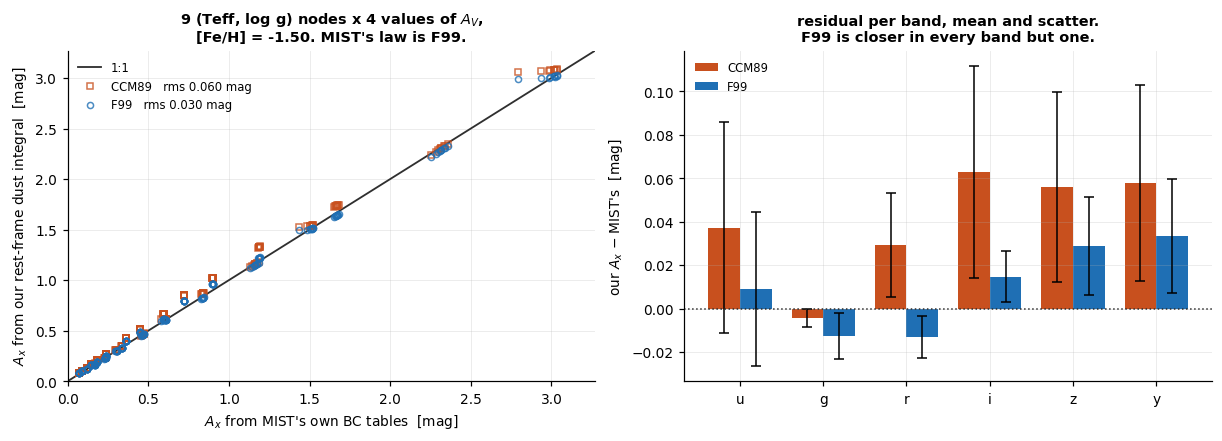

In [21]:
status, detail, d = RT["mist_av_roundtrip"]
show(status, detail)

theirs = np.array(d["theirs"])
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.9), constrained_layout=True)
ax = axes[0]
lims = [0, max(theirs.max(), max(np.array(v).max() for v in d["ours"].values())) * 1.06]
ax.plot(lims, lims, "-", color=C["truth"], lw=1.2, label="1:1")
for law, col, mk in (("CCM89", C["theirs"], "s"), ("F99", C["ours"], "o")):
    o = np.array(d["ours"][law])
    ax.plot(theirs.ravel(), o.ravel(), mk, ms=4, mfc="none", mec=col, mew=1.0,
            alpha=0.8, label=f"{law}   rms {d['rms'][law]:.3f} mag")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(r"$A_x$ from MIST's own BC tables  [mag]")
ax.set_ylabel(r"$A_x$ from our rest-frame dust integral  [mag]")
ax.set_title(f"9 (Teff, log g) nodes x {len(d['av'])} values of $A_V$,\n"
             f"[Fe/H] = {d['feh']}. MIST's law is {d['best']}.")
ax.legend(fontsize=7.6)

ax = axes[1]
bands6 = d["bands"]; x = np.arange(len(bands6)); w2 = 0.38
for off, law, col in ((-w2/2, "CCM89", C["theirs"]), (w2/2, "F99", C["ours"])):
    mean = [d["stats"][law][b][0] for b in bands6]
    std = [d["stats"][law][b][1] for b in bands6]
    ax.bar(x + off, mean, w2, yerr=std, capsize=3, color=col, label=law,
           error_kw=dict(lw=1.0))
ax.axhline(0, color=C["truth"], lw=1.0, ls=":")
ax.set_xticks(x); ax.set_xticklabels([b.split("_")[-1] for b in bands6])
ax.set_ylabel(r"our $A_x$ $-$ MIST's  [mag]")
ax.set_title("residual per band, mean and scatter.\nF99 is closer in every band but one.")
ax.legend(fontsize=7.6)
plt.show()

### R5.2 · `check_extinction_frames` — the two frames separate, and by how much

**What is being tested.** One `A_V` = 1 screen, applied first as host dust and
then as foreground dust, on the same red-giant spectrum, over a range of
redshifts. Plus the cross term: what you lose by adding the two separately
instead of computing them together.

**Why it matters.** Until now ALVISS's dust has been a Milky Way foreground
screen computed at `z = 0` — which is correct today and becomes wrong as soon as
the renderer moves off zero. The measurement says how wrong: at `z = 0.05` with
`A_V` = 1, the two frames differ by **0.035–0.073 mag** depending on band. That
is the same size as the K-correction itself in the red bands, so it is not a
detail.

**The cross term** is non-zero even at `z = 0`, because extinction in a broad
band saturates — the reddest photons in the band survive preferentially, so
`A(A₁ + A₂) ≠ A(A₁) + A(A₂)`. Computing one integral with both screens carries
it exactly; composing two separately computed terms would drop it.

**The check's own sanity condition** is that the two frames are *identical* at
`z = 0` (to machine precision) and *separate* by `z = 0.2`. Either failing would
mean one of the two paths is not doing what it says.

✅  PASS
    A_V = 1.0 applied in the host frame vs the observer frame, |A_host - A_MW| at z=0.05: u=0.057
    g=0.073  r=0.059  i=0.050  z=0.042  y=0.035 mag (0.000 in every band at z=0, by construction); cross
    term 0.009 mag at worst


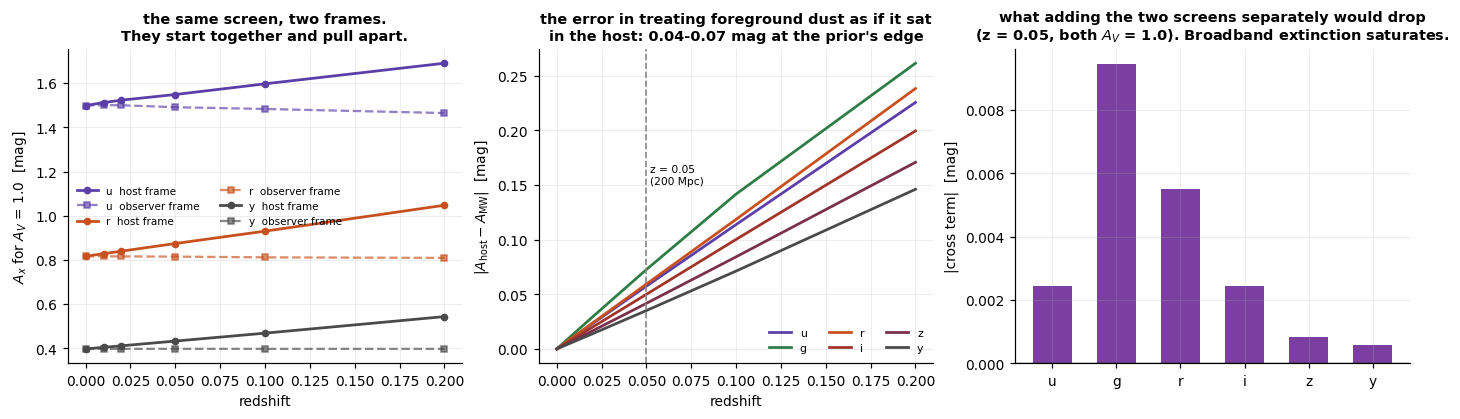

In [22]:
status, detail, d = RT["extinction_frames"]
show(status, detail)

zs = np.array(d["z_scan"]); host = np.array(d["host"]); mw = np.array(d["mw"])
cross = np.array(d["cross"]); bands6 = d["bands"]
fig, axes = plt.subplots(1, 3, figsize=(12.8, 3.7), constrained_layout=True)

ax = axes[0]
for b, j in (("LSST_u", 0), ("LSST_r", 2), ("LSST_y", 5)):
    ax.plot(zs, host[:, j], "-o", ms=4, lw=1.8, color=BANDC[b],
            label=f"{b.split('_')[-1]}  host frame")
    ax.plot(zs, mw[:, j], "--s", ms=4, lw=1.5, color=BANDC[b], alpha=0.65,
            label=f"{b.split('_')[-1]}  observer frame")
ax.set_xlabel("redshift"); ax.set_ylabel(rf"$A_x$ for $A_V$ = {d['a_v']}  [mag]")
ax.set_title("the same screen, two frames.\nThey start together and pull apart.")
ax.legend(fontsize=6.8, ncol=2)

ax = axes[1]
for j, b in enumerate(bands6):
    ax.plot(zs, np.abs(host[:, j] - mw[:, j]), "-", lw=1.8, color=BANDC[b],
            label=b.split("_")[-1])
ax.axvline(0.05, color=C["muted"], lw=1.1, ls="--")
ax.text(0.052, ax.get_ylim()[1] * 0.55, "z = 0.05\n(200 Mpc)", fontsize=7.0)
ax.set_xlabel("redshift"); ax.set_ylabel(r"$|A_{\rm host} - A_{\rm MW}|$  [mag]")
ax.set_title("the error in treating foreground dust as if it sat\n"
             "in the host: 0.04-0.07 mag at the prior's edge")
ax.legend(fontsize=7.2, ncol=3)

ax = axes[2]
x = np.arange(len(bands6))
i_ref = d["i_ref"]
ax.bar(x, np.abs(cross[i_ref]), 0.6, color=C["alt"])
ax.axhline(0, color=C["truth"], lw=0.9)
ax.set_xticks(x); ax.set_xticklabels([b.split("_")[-1] for b in bands6])
ax.set_ylabel("|cross term|  [mag]")
ax.set_title(f"what adding the two screens separately would drop\n"
             f"(z = {zs[i_ref]:.2f}, both $A_V$ = {d['a_v']}). Broadband extinction saturates.")
plt.show()

### R5.3 · The extinction unit tests — `x1`–`x5`

Five assertions that pin the dust machinery where an exact answer exists.

| test | the claim, and why it is the right thing to assert |
|---|---|
| `x1` | a **grey** (wavelength-independent) screen gives `A_x = A_V` exactly, in either frame and at any redshift. With a grey law the attenuation factors straight out of the integral, so anything left over is a misplaced `(1+z)` inside the dust term |
| `x2` | at `z = 0` the two frames are the same operation, to machine precision. This is the degeneracy that hid the distinction; asserting it makes the `z > 0` separation a measurement rather than a possible bug in one path |
| `x3` | at `z > 0` they separate, and the separation **grows monotonically** with redshift |
| `x4` | `A_V = 0` changes nothing, bit for bit |
| `x5` | the cross term is non-zero — so composing separate terms *would* be wrong — and bounded, so the one-integral form has not gone haywire |

  ✅ PASS  test_x1_grey_screen_is_exactly_a_v               grey law -> A_x = A_V exactly, any frame, any z
  ✅ PASS  test_x2_frames_coincide_at_zero_redshift         the two frames are identical at z = 0
  ✅ PASS  test_x3_frames_separate_at_nonzero_redshift      and separate monotonically above it
  ✅ PASS  test_x4_zero_extinction_is_a_no_op               A_V = 0 is bit-identical
  ✅ PASS  test_x5_cross_term_is_reported_not_assumed_zero  cross term non-zero and bounded


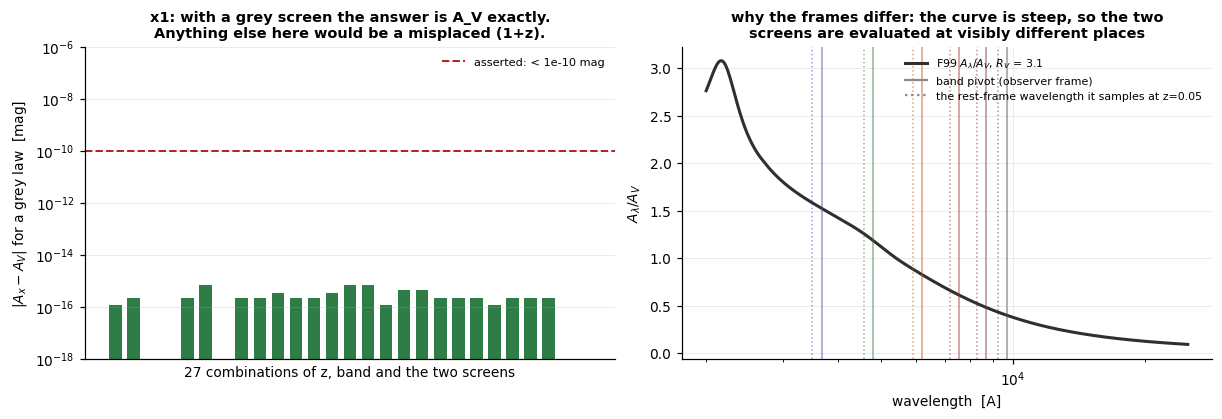

In [23]:
ext_tests = [
    ("test_x1_grey_screen_is_exactly_a_v", "grey law -> A_x = A_V exactly, any frame, any z"),
    ("test_x2_frames_coincide_at_zero_redshift", "the two frames are identical at z = 0"),
    ("test_x3_frames_separate_at_nonzero_redshift", "and separate monotonically above it"),
    ("test_x4_zero_extinction_is_a_no_op", "A_V = 0 is bit-identical"),
    ("test_x5_cross_term_is_reported_not_assumed_zero", "cross term non-zero and bounded"),
]
verdict_table([n for n, _ in ext_tests],
              {n: FORK.get("TestExtinctionFrames." + n, ("SKIP", "")) for n, _ in ext_tests},
              dict(ext_tests))

lam_x = np.geomspace(500., 60000., 40000)
sed_x = planck_lam(lam_x, 4000.)
grey = extinction_curve("grey")
f99 = extinction_curve("F99")
zs_x = [0.0, 0.05, 0.2]
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.7), constrained_layout=True)

ax = axes[0]
res = []
for z in zs_x:
    for b in ("LSST_u", "LSST_r", "LSST_y"):
        base = band_offset(lam_x, sed_x, *fs.get_trans(b), redshift=z, ext=grey)
        for ah, am in ((0.7, 0.0), (0.0, 1.3), (0.4, 0.9)):
            got = band_offset(lam_x, sed_x, *fs.get_trans(b), redshift=z,
                              a_v_host=ah, a_v_mw=am, ext=grey)
            res.append(abs((got - base) - (ah + am)))
ax.bar(range(len(res)), np.maximum(res, 1e-18), 0.7, color=C["ok"])
ax.axhline(1e-10, color=C["bad"], lw=1.3, ls="--", label="asserted: < 1e-10 mag")
ax.set_yscale("log"); ax.set_ylim(1e-18, 1e-6)
ax.set_xticks([]); ax.set_xlabel("27 combinations of z, band and the two screens")
ax.set_ylabel(r"$|A_x - A_V|$ for a grey law  [mag]")
ax.set_title("x1: with a grey screen the answer is A_V exactly.\n"
             "Anything else here would be a misplaced (1+z).")
ax.legend(fontsize=7.4)

ax = axes[1]
lam_plot = np.geomspace(2000., 25000., 400)
ax.plot(lam_plot, f99(lam_plot), "-", lw=2.0, color=C["truth"],
        label=r"F99 $A_\lambda / A_V$, $R_V$ = 3.1")
for b in list(BANDC):
    lw_, tt_ = fs.get_trans(b)
    piv = np.exp(np.trapezoid(np.log(lw_) * tt_, lw_) / np.trapezoid(tt_, lw_))
    ax.axvline(piv, color=BANDC[b], lw=1.0, alpha=0.55)
    ax.axvline(piv / 1.05, color=BANDC[b], lw=1.0, ls=":", alpha=0.55)
ax.plot([], [], "-", color=C["muted"], label="band pivot (observer frame)")
ax.plot([], [], ":", color=C["muted"], label="the rest-frame wavelength it samples at z=0.05")
ax.set_xscale("log"); ax.set_xlabel("wavelength  [A]"); ax.set_ylabel(r"$A_\lambda / A_V$")
ax.set_title("why the frames differ: the curve is steep, so the two\n"
             "screens are evaluated at visibly different places")
ax.legend(fontsize=7.2)
plt.show()

---
# §R6 — Geometry, and the one term nothing in the code computes

Flux and angles need *different distances*.

Flux falls off with the **luminosity distance** `D_L`. Angles are set by the
**angular-diameter distance** `D_A`. The two are related by
`D_A = D_L / [(1+z)² η²]` — Etherington's distance-duality relation, which
follows from photon conservation in any metric theory and is *not* a
cosmological model. `η` is exposed as a parameter so a violation of duality can
itself be probed, and `distance_angular` overrides the relation entirely for
anyone who wants the decoupling to be literal.

**This is the only place in the design where two of the three free parameters
are related**, which is why it is a visible method with a visible `η` rather
than a hidden conversion buried in a coordinate transform.

Everything else follows, and one thing follows that nobody codes. Because
`D_A < D_L`, a fixed physical size subtends a **larger** angle at higher
redshift. Same flux, more sky, so the surface brightness drops — by exactly
`10 log₁₀(1+z)`, the classical Tolman dimming. There is no line of code
computing that. It has to *emerge* from using the two distances for the two
jobs, and §R6.2 is where that is checked rather than assumed.

*(An implementation note that mattered: the angular-diameter distance is handed
to the star-position sampler as its `distance` argument rather than being
patched into the four places `arctan2(r_eff, distance)` appears. ALVISS replaces
one of those four at import time with its own memory-efficient sampler, so a fix
written into the function body would have been silently discarded.)*

### R6.1 · `check_distance_flux_power` — the backfill, written first

**What is being tested.** Move one already-built population — the same stars, no
resampling — between 20 and 200 Mpc, and check that its total magnitude and its
fluctuation magnitude both shift by exactly `5 log₁₀(d₂/d₁)`. Then render it at
two distances and check the flux on the pixels falls as `D_L⁻²`.

**Why it matters, and why it is here.** This has nothing to do with redshift.
It is a gap that existed before any of this work: the test suite's distances
were fixed constants and nothing isolated the distance-to-flux power. Writing it
*before* touching the distance path means the refactor was guarded rather than
trusted. The residual is `4 × 10⁻¹⁵` mag — this is arithmetic, and it should read
as arithmetic.

✅  PASS
    total_mag and mbar both move by exactly 5log10(d2/d1) over 20-200 Mpc (max residual 3.55e-15 mag);
    rendered flux ratio between 50 and 100 Mpc = 3.996 (D_L^-2 predicts 4.000)


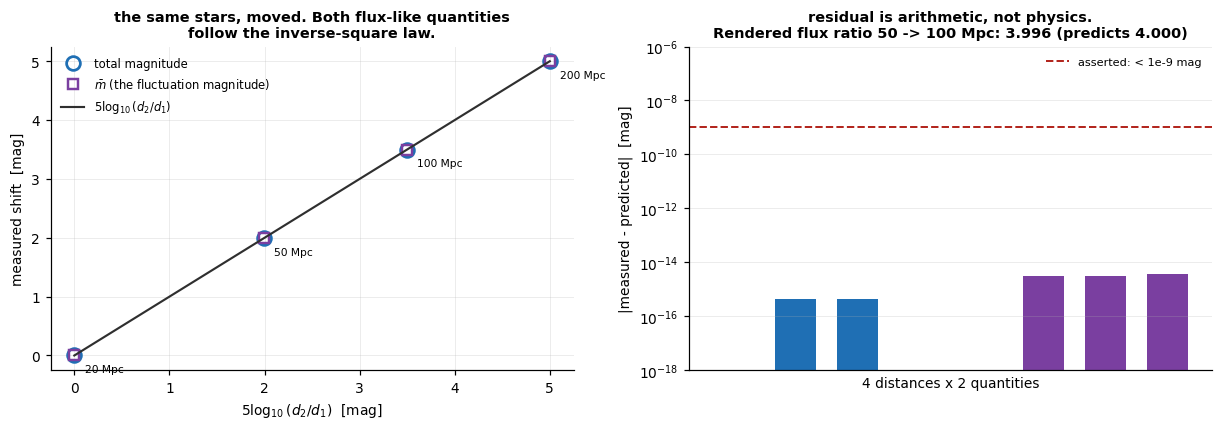

In [24]:
status, detail, d = RT["distance_flux_power"]
show(status, detail)

dist = np.array(d["distances"]); tot = np.array(d["total_mag"])
sbf = np.array(d["sbf_mag"]); pred = np.array(d["predicted"])
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8), constrained_layout=True)

ax = axes[0]
ax.plot(pred, tot - tot[0], "o", ms=9, mfc="none", mec=C["ours"], mew=1.8,
        label="total magnitude")
ax.plot(pred, sbf - sbf[0], "s", ms=7, mfc="none", mec=C["alt"], mew=1.6,
        label=r"$\bar m$ (the fluctuation magnitude)")
ax.plot(pred, pred, "-", lw=1.4, color=C["truth"], label=r"$5\log_{10}(d_2/d_1)$")
for x_, dd in zip(pred, dist):
    ax.annotate(f"{dd:.0f} Mpc", (x_, x_), textcoords="offset points",
                xytext=(7, -11), fontsize=7.0)
ax.set_xlabel(r"$5\log_{10}(d_2/d_1)$  [mag]"); ax.set_ylabel("measured shift  [mag]")
ax.set_title("the same stars, moved. Both flux-like quantities\nfollow the inverse-square law.")
ax.legend(fontsize=7.6)

ax = axes[1]
resid = np.abs(np.concatenate([(tot - tot[0]) - pred, (sbf - sbf[0]) - pred]))
ax.bar(range(len(resid)), np.maximum(resid, 1e-18), 0.66,
       color=[C["ours"]] * len(pred) + [C["alt"]] * len(pred))
ax.axhline(1e-9, color=C["bad"], lw=1.3, ls="--", label="asserted: < 1e-9 mag")
ax.set_yscale("log"); ax.set_ylim(1e-18, 1e-6)
ax.set_xticks([]); ax.set_xlabel("4 distances x 2 quantities")
ax.set_ylabel("|measured - predicted|  [mag]")
ax.set_title(f"residual is arithmetic, not physics.\n"
             f"Rendered flux ratio 50 -> 100 Mpc: {d['rendered_ratio']:.3f} (predicts 4.000)")
ax.legend(fontsize=7.4)
plt.show()

### R6.2 · `check_surface_brightness_dimming` — the emergent test

**What is being tested.** Take one population and render it twice at the same
luminosity distance, with the angular scale set once for `z = 0` and once for
`z > 0`. The stars are *identical* — the population's random state is reset
between renders — so the flux is unchanged by construction and anything the
surface brightness does is geometry and nothing else.

**Why it matters.** No line of code computes surface-brightness dimming. It has
to fall out of `D_L` setting the flux and `D_A` setting the solid angle. This is
the one place where a plumbing mistake — using `D_L` for the angular scale, or
`D_A` for the flux — produces an answer that is smooth, plausible and wrong. So
the `10 log₁₀(1+z)` is *asserted*, to `3 × 10⁻¹¹` mag.

**Why the stars are held fixed.** Building two populations instead would
resample them, and the Poisson scatter on a few hundred stars is larger than the
effect being measured. The physically complete statement — a genuinely
redshifted population, correction and all — is reported alongside, and matches
`K_int + 10 log₁₀(1+z)` to 0.001 mag.

**And the half-light radius is measured off the rendered image**, not read from
the model. The smooth Sérsic profile and the star positions are produced by two
different code paths; if only the model had been given `D_A`, the analytic check
would pass and the picture would not.

✅  PASS
    same stars, two angular scales: mu moves by exactly 10log10(1+z) to 3.36e-11 mag, and the RENDERED
    half-light radius follows (1+z)^+2 to 1.9% (cutout aperture loss 0.001 mag, excluded)
      with the photometry too (a real z=0.05 population): d(mu) = +0.207 vs K_int + 10log10(1+z) =
    +0.208, residual 0.001 mag (a different Poisson draw: 527 vs 605 stars)


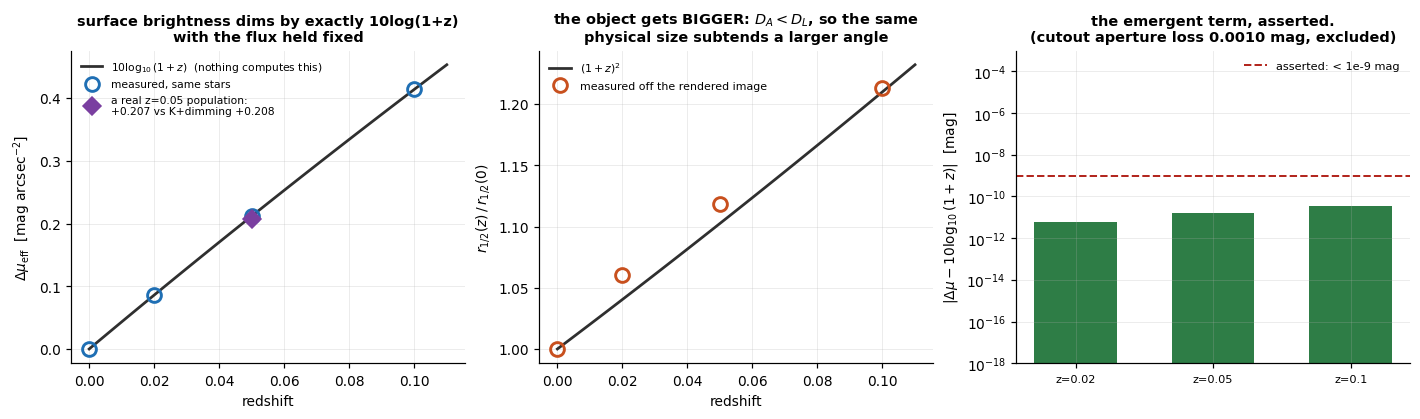

In [25]:
status, detail, d = RT["surface_brightness_dimming"]
show(status, detail)

rows = d["rows"]; ref = rows[0]
zz = np.array([r["z"] for r in rows])
dmu = np.array([r["mu"] - ref["mu"] for r in rows])
rr = np.array([r["r_half"] / ref["r_half"] for r in rows])
fig, axes = plt.subplots(1, 3, figsize=(12.8, 3.7), constrained_layout=True)

ax = axes[0]
zf = np.linspace(0, 0.11, 60)
ax.plot(zf, 10 * np.log10(1 + zf), "-", lw=1.8, color=C["truth"],
        label=r"$10\log_{10}(1+z)$  (nothing computes this)")
ax.plot(zz, dmu, "o", ms=9, mfc="none", mec=C["ours"], mew=1.9,
        label="measured, same stars")
p = d["physical"]
ax.plot([0.05], [p["d_mu"]], "D", ms=8, color=C["alt"],
        label=f"a real z=0.05 population:\n{p['d_mu']:+.3f} vs K+dimming {p['predicted']:+.3f}")
ax.set_xlabel("redshift"); ax.set_ylabel(r"$\Delta\mu_{\rm eff}$  [mag arcsec$^{-2}$]")
ax.set_title("surface brightness dims by exactly 10log(1+z)\nwith the flux held fixed")
ax.legend(fontsize=7.0)

ax = axes[1]
ax.plot(zf, (1 + zf) ** 2, "-", lw=1.8, color=C["truth"], label=r"$(1+z)^{2}$")
ax.plot(zz, rr, "o", ms=9, mfc="none", mec=C["theirs"], mew=1.9,
        label="measured off the rendered image")
ax.set_xlabel("redshift"); ax.set_ylabel(r"$r_{1/2}(z)\,/\,r_{1/2}(0)$")
ax.set_title(r"the object gets BIGGER: $D_A < D_L$, so the same"
             "\nphysical size subtends a larger angle")
ax.legend(fontsize=7.2)

ax = axes[2]
ax.bar(range(len(d["resid"])), np.maximum(d["resid"], 1e-18), 0.6, color=C["ok"])
ax.axhline(1e-9, color=C["bad"], lw=1.3, ls="--", label="asserted: < 1e-9 mag")
ax.set_yscale("log"); ax.set_ylim(1e-18, 1e-3)
ax.set_xticks(range(len(d["resid"])))
ax.set_xticklabels([f"z={r['z']}" for r in rows[1:]], fontsize=7.4)
ax.set_ylabel(r"$|\Delta\mu - 10\log_{10}(1+z)|$  [mag]")
ax.set_title(f"the emergent term, asserted.\n"
             f"(cutout aperture loss {d['aperture_loss']:.4f} mag, excluded)")
ax.legend(fontsize=7.4)
plt.show()

### R6.3 · `check_distance_redshift_separable` — the two are not degenerate

**What is being tested.** How the rendered image responds to distance versus how
it responds to redshift, in flux and in angular size at once.

**Why it matters.** This is the design's central commitment stated as a
measurement. `distance`, `redshift` and `r_eff` are three free arguments, and
nothing derives any of them from another, precisely so that `μ(z)` remains
something data can constrain rather than something this simulator assumed. That
only buys anything if the three are actually distinguishable in the output.

They are, and not marginally: doubling the distance dims by 1.505 mag and
*halves* the angular size, while a redshift of 0.10 dims by 0.002 mag and
*grows* the angular size by 21%. The two responses point in opposite directions
in the (flux, size) plane.

Photometry is compared analytically and geometry on rendered images with the
stars held fixed, so that a Poisson draw cannot masquerade as signal in either.

✅  PASS
    doubling D_L: dm = +1.505 (5log10 2 = +1.505), size x0.500 (0.500)
      z = 0.10 at fixed D_L: dm = +0.002 (K only), size x1.213 (1.210) -- the two responses differ by
    637x in flux at comparable size change, so they are not degenerate


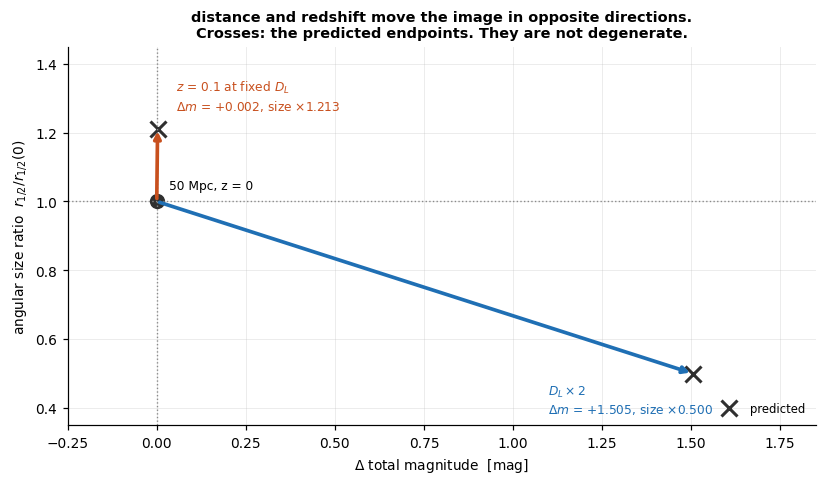

In [26]:
status, detail, d = RT["distance_redshift_separable"]
show(status, detail)

fig, ax = plt.subplots(figsize=(7.4, 4.3), constrained_layout=True)
ax.annotate("", xy=(d["dm_distance"], d["size_ratio_distance"]), xytext=(0, 1),
            arrowprops=dict(arrowstyle="-|>", lw=2.4, color=C["ours"]))
ax.annotate("", xy=(d["dm_redshift"], d["size_ratio_redshift"]), xytext=(0, 1),
            arrowprops=dict(arrowstyle="-|>", lw=2.4, color=C["theirs"]))
ax.plot(0, 1, "o", ms=9, color=C["truth"])
ax.annotate("50 Mpc, z = 0", (0, 1), textcoords="offset points", xytext=(8, 8),
            fontsize=8)
ax.annotate(f"$D_L \\times 2$\n$\\Delta m$ = {d['dm_distance']:+.3f}, size $\\times${d['size_ratio_distance']:.3f}",
            (d["dm_distance"], d["size_ratio_distance"]), textcoords="offset points",
            xytext=(-95, -26), fontsize=8, color=C["ours"])
ax.annotate(f"$z$ = {d['z']} at fixed $D_L$\n$\\Delta m$ = {d['dm_redshift']:+.3f}, size $\\times${d['size_ratio_redshift']:.3f}",
            (d["dm_redshift"], d["size_ratio_redshift"]), textcoords="offset points",
            xytext=(12, 12), fontsize=8, color=C["theirs"])
ax.plot(d["dm_distance"], d["predicted_size_distance"], "x", ms=10, mew=2,
        color=C["truth"], label="predicted")
ax.plot(d["dm_redshift"], d["predicted_size_redshift"], "x", ms=10, mew=2,
        color=C["truth"])
ax.axhline(1, color=C["muted"], lw=0.9, ls=":")
ax.axvline(0, color=C["muted"], lw=0.9, ls=":")
ax.set_xlim(-0.25, 1.85); ax.set_ylim(0.35, 1.45)
ax.set_xlabel(r"$\Delta$ total magnitude  [mag]")
ax.set_ylabel(r"angular size ratio  $r_{1/2}/r_{1/2}(0)$")
ax.set_title("distance and redshift move the image in opposite directions.\n"
             "Crosses: the predicted endpoints. They are not degenerate.")
ax.legend(fontsize=7.6, loc="lower right")
plt.show()

### R6.4 · `c7` and `c8` — the duality relation and its two escape hatches

| test | the claim |
|---|---|
| `c7` | at fixed `D_L` and fixed physical size, the angular size grows as `(1+z)²`. The *direction* is the part worth pinning — it is easy to get backwards, and a sign error there would produce dimming of the right magnitude and the wrong sign |
| `c8` | `eta=` scales the relation so a duality violation can be probed, and `distance_angular=` bypasses it entirely. The test also checks that the star sampler is handed the same distance as the smooth model — the two are separate code paths and only one of them is obvious |

  ✅ PASS  test_c7_angular_size_grows_as_one_plus_z_squared       angular size grows as (1+z)^2; sampler and model agree
  ✅ PASS  test_c8_eta_and_distance_angular_override_the_default  eta= and distance_angular= both bypass the default


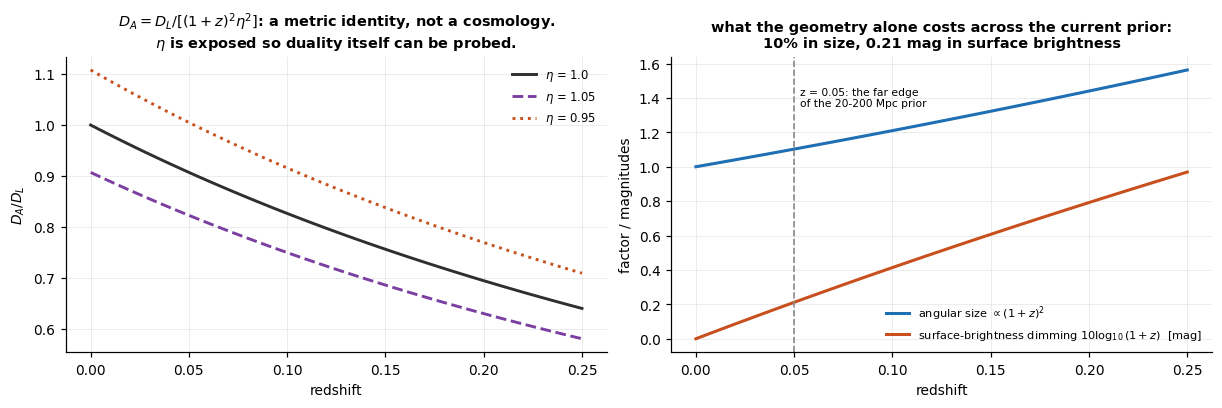

In [27]:
geo = [("test_c7_angular_size_grows_as_one_plus_z_squared",
        "angular size grows as (1+z)^2; sampler and model agree"),
       ("test_c8_eta_and_distance_angular_override_the_default",
        "eta= and distance_angular= both bypass the default")]
verdict_table([n for n, _ in geo],
              {n: FORK.get("TestRedshiftIntegration." + n, ("SKIP", "")) for n, _ in geo},
              dict(geo))

zf = np.linspace(0, 0.25, 100)
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.6), constrained_layout=True)
ax = axes[0]
for eta, ls, col in ((1.0, "-", C["truth"]), (1.05, "--", C["alt"]),
                     (0.95, ":", C["theirs"])):
    ax.plot(zf, 1.0 / ((1 + zf) ** 2 * eta ** 2), ls, lw=1.9, color=col,
            label=rf"$\eta$ = {eta}")
ax.set_xlabel("redshift"); ax.set_ylabel(r"$D_A / D_L$")
ax.set_title(r"$D_A = D_L/[(1+z)^2\eta^2]$: a metric identity, not a cosmology."
             "\n" r"$\eta$ is exposed so duality itself can be probed.")
ax.legend(fontsize=7.6)

ax = axes[1]
ax.plot(zf, (1 + zf) ** 2, "-", lw=2.0, color=C["ours"], label=r"angular size $\propto (1+z)^2$")
ax.plot(zf, 10 * np.log10(1 + zf), "-", lw=2.0, color=C["theirs"],
        label=r"surface-brightness dimming $10\log_{10}(1+z)$  [mag]")
ax.axvline(0.05, color=C["muted"], lw=1.1, ls="--")
ax.text(0.053, 1.35, "z = 0.05: the far edge\nof the 20-200 Mpc prior", fontsize=7.0)
ax.set_xlabel("redshift"); ax.set_ylabel("factor / magnitudes")
ax.set_title("what the geometry alone costs across the current prior:\n"
             "10% in size, 0.21 mag in surface brightness")
ax.legend(fontsize=7.4)
plt.show()

---
# §R7 — Is the signal bigger than the uncertainty on the signal?

Every correction is only worth applying if it is larger than the error in
computing it. This section puts the two on one axis.

Three numbers per band:

* **the signal** — the correction a real 10 Gyr population actually picks up at
  `z = 0.05`, both flux-weighted (what the total magnitude does) and
  `f²`-weighted (what the fluctuation magnitude does), plus the star-to-star
  spread;
* **the measured library systematic** — how much the correction moves when C3K
  is used at `R = 100` instead of `R = 3000`, at the same isochrone rows. A real,
  in-family perturbation, and therefore the empirical floor;
* **the propagated colour scatter** — C3K through these filter curves disagrees
  with MIST's own bolometric-correction colours by 0.002–0.059 mag
  (`verify_c3k_staging.check_bc_colours`). A K-correction is, to first order, a
  colour over a baseline of `ln(1+z)` in wavelength, while that scatter was
  measured over a broadband colour baseline, so it scales down by
  `ln(1+z)/Δln λ`. That is an order-of-magnitude propagation, not a derivation,
  and it is labelled as one.

**What the comparison shows.** The per-star spread beats the systematic by 18×
at worst. The flux-weighted mean does *not*, in `i` — but that is because it
passes through zero there, which is the same fact as `K_int` changing sign across
the bands, and says nothing about whether the correction matters. What matters is
the spread and the `f²`-weighted value, and those are the ones asserted.

### R7.1 · `check_error_budget`

✅  PASS
    band      K_int    K_SBF   spread(5-95)   R-systematic   propagated scatter
      u       +0.180   +0.236      0.655          0.0008         0.0051
      g       +0.101   +0.189      0.481          0.0001         0.0051
      r       +0.026   +0.078      0.300          0.0001         0.0044
      i       -0.004   +0.032      0.248          0.0103         0.0034
      z       -0.019   +0.018      0.202          0.0012         0.0021
      y       -0.027   +0.001      0.201          0.0114         0.0021
      the per-star spread exceeds the measured library systematic by 18x at worst; so does the SBF-
    weighted correction in every band but y (0.1x there, where K_SBF is only 0.001 mag at this redshift)


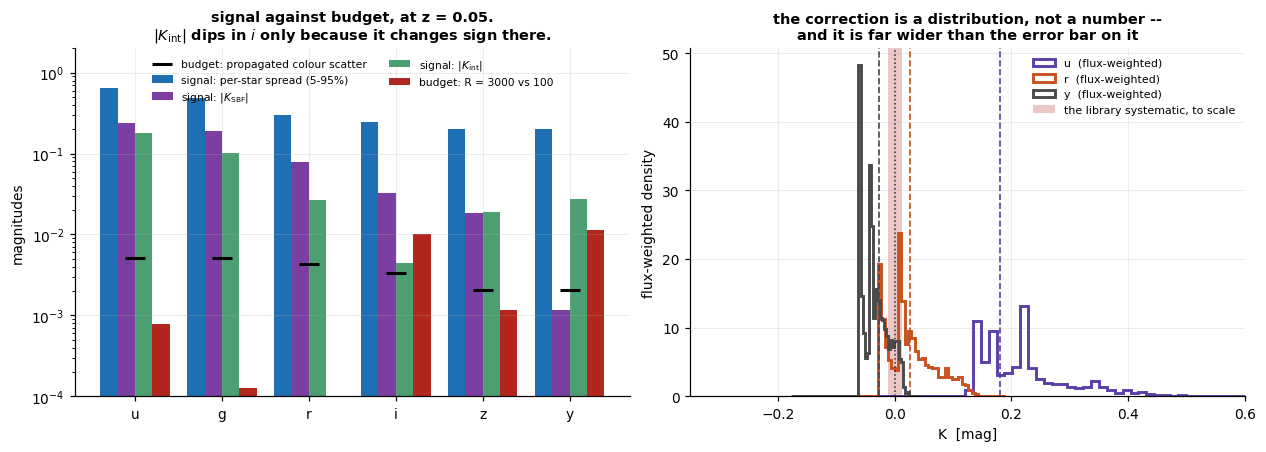

In [28]:
status, detail, d = RT["error_budget"]
show(status, detail)

rows = d["rows"]; bands6 = [r[0] for r in rows]
x = np.arange(len(rows))
k_int = np.array([r[1] for r in rows]); k_sbf = np.array([r[2] for r in rows])
spread = np.array([r[3] for r in rows]); sysm = np.array([r[4] for r in rows])
scat = np.array([r[5] for r in rows])

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.0), constrained_layout=True)
ax = axes[0]
w2 = 0.2
ax.bar(x - 1.5 * w2, spread, w2, color=C["ours"], label="signal: per-star spread (5-95%)")
ax.bar(x - 0.5 * w2, np.abs(k_sbf), w2, color=C["alt"], label=r"signal: $|K_{\rm SBF}|$")
ax.bar(x + 0.5 * w2, np.abs(k_int), w2, color=C["smooth"], label=r"signal: $|K_{\rm int}|$")
ax.bar(x + 1.5 * w2, sysm, w2, color=C["bad"], label="budget: R = 3000 vs 100")
ax.plot(x, scat, "k_", ms=13, mew=2, label="budget: propagated colour scatter")
ax.set_yscale("log"); ax.set_ylim(1e-4, 2)
ax.set_xticks(x); ax.set_xticklabels([b.split("_")[-1] for b in bands6])
ax.set_ylabel("magnitudes")
ax.set_title("signal against budget, at z = 0.05.\n"
             r"$|K_{\rm int}|$ dips in $i$ only because it changes sign there.")
ax.legend(fontsize=7.0, ncol=2, loc="upper center")

ax = axes[1]
for b in ("LSST_u", "LSST_r", "LSST_y"):
    k = np.array(d["k_hr"][b])
    ax.hist(k, bins=60, histtype="step", lw=1.9, color=BANDC[b],
            weights=np.array(d["flux_weight"]), density=True,
            label=f"{b.split('_')[-1]}  (flux-weighted)")
    j = bands6.index(b)
    ax.axvline(k_int[j], color=BANDC[b], lw=1.1, ls="--")
ax.axvline(0, color=C["truth"], lw=1.0, ls=":")
ax.axvspan(-0.012, 0.012, color=C["bad"], alpha=0.25, lw=0,
           label="the library systematic, to scale")
ax.set_xlabel("K  [mag]"); ax.set_ylabel("flux-weighted density")
ax.set_xlim(-0.35, 0.6)
ax.set_title("the correction is a distribution, not a number --\n"
             "and it is far wider than the error bar on it")
ax.legend(fontsize=7.2)
plt.show()

---
# §R8 — What this settles, and what it does not

## Settled here

1. **The correction is per star, and it has to be.** It varies by 0.10–0.42 mag
   across the stars of one 10 Gyr population at `z = 0.05` (§R1.1), which is 4–10×
   the threshold at which a per-galaxy scalar would have been defensible.
2. **The fluctuation correction is not the integrated-light one.** They differ by
   0.02–0.18 mag and the integrated one changes sign across the bands while the
   `f²`-weighted one does not (§R1.2). Since `m̄` is this project's distance
   indicator, a galaxy-level correction would have put a ~10% error into a
   published distance while looking entirely reasonable.
3. **The bookkeeping is right.** The `(1+z)` prefactor and the photon-counting
   convention are pinned by two closed-form identities to `10⁻⁷` mag, four orders
   below tolerance (§R2.1, §R2.2), with an independent-route check (§R2.4).
4. **`redshift=0.0` is bit-identical to the renderer as it stood before this
   work** — magnitudes, both population moments and a rendered image, asserted
   with `array_equal` rather than a tolerance (§R4.1). Every parameter added
   here defaults to today's behaviour, and the correction's `z = 0` value is
   not merely small but identically zero, so the default path is unchanged
   byte for byte.
5. **Every spectral-library switch is recorded.** The fallback carries under
   0.001% of the fluctuation weight (§R3.1), and the differential form suppresses
   the C3K/Tremblay seam by 7–27× (§R3.2).
6. **MIST's reddening law is Fitzpatrick (1999)**, measured rather than assumed
   — 0.030 mag rms against MIST's own `A_V` axis, versus 0.060 for CCM89 (§R5.1).
   That is also what ALVISS already uses.
7. **The two dust frames differ by 0.035–0.073 mag at `z = 0.05`** for `A_V = 1`
   (§R5.2), comparable to the K-correction itself in the red bands.
8. **Surface-brightness dimming emerges correctly**, to `3 × 10⁻¹¹` mag, from
   nothing but using `D_L` for flux and `D_A` for solid angle (§R6.2).
9. **C3K's wavelengths are vacuum and Tremblay's are air.**
   `HANDOFF_REDSHIFT.md` §1b left this open on the grounds that `R = 3000` was
   too coarse to settle it from one line centre. Nine lines settle it: they sit
   at their vacuum wavelengths to better than `0.3 × 10⁻⁴` fractional, against a
   `2.77 × 10⁻⁴` air offset.

## Corrected while building this

* **§R3.3** — the handoff's claim that cooler stars have larger corrections in
  the blue "across the grid" is **false in `u` and `z`**. Both turn back up at
  the hot end, where the Balmer and Paschen jumps cross the filter. The test
  asserts the ordering where it holds and asserts the turns where they exist.
* **§R3.2** — the handoff asked for the library seam to be *continuous*. It is
  not, and should not be: the two libraries describe different stars. What is
  worth asserting, and now is, is the suppression factor.
* **§R6** — the angular size **grows** with redshift at fixed `D_L`, because
  `D_A < D_L`. Easy to get backwards, and a sign error there would produce
  dimming of the right size and the wrong sign.

## Still open

* **The ALVISS seam is not yet tested.** `alviss_tests.py` and
  `alviss_inject.py` were deliberately left untouched. The angular-diameter
  distance reaches ALVISS's monkey-patched sampler correctly — it is passed as
  the sampler's `distance` argument rather than patched into a function body it
  replaces — so the seam is *correct* today, but that is an argument and not a
  test. Tier D of `HANDOFF_REDSHIFT.md` §6 is the next handoff.
* **`APPROXIMATIONS.md` still has no redshift section.** The file's own
  convention is to record what was approximated and why; the treatment here, the
  library floor, the coverage limits and the extinction-frame caveat all belong
  in it.
* **The catalogue has no redshift prior.** Deliberate: the renderer takes `z` as
  a free argument and the caller samples it however it likes. Nothing derives
  `z` from `D_L` or `D_L` from `z`, anywhere, so `μ(z)` stays something the data
  can constrain.
* **Nothing has been re-rendered.** The existing `alviss_cutouts_*.h5` were made
  by the `z = 0` renderer and remain valid as such; a redshift-aware re-render is
  accounted for in the handoff but not scheduled.
* **Euclid** is separable and cheap — MIST v2.5 ships the tables upstream — and
  the K machinery would pick up a third survey for free.

---

### Reproducing this

```bash
# from the fork (this notebook lives here)
cd ArtPop
python -m pytest tests/ -q                       # 72 passed, 18 subtests
python tools/build_filter_data.py --check
python tools/build_kcorrection_grid.py --check
jupyter nbconvert --to notebook --execute --inplace \
  --ExecutePreprocessor.timeout=2400 visualize_redshift_tests.ipynb

# from the repo root
cd ..
python verify_c3k_staging.py                     # 5 passed
python redshift_tests.py                         # 12 passed
python redshift_tests.py --json > /tmp/rt.json   # machine-readable
```
